# HMM 레짐 분석 (Hidden Markov Model Regime Analysis)

> **목적**: 시장 데이터를 기반으로 숨겨진 시장 상태(레짐)를 자동 탐지합니다.  
> **데이터**: FF 팩터, 매크로 지표, 일별 수익률, 섹터 ETF  
> **기간**: 2004 ~ 2026  

---


In [57]:
import subprocess, sys
pkgs = ["hmmlearn", "scikit-learn", "matplotlib", "seaborn", "nbformat"]
for p in pkgs:
    result = subprocess.run(
        ["uv", "pip", "install", p, "--python", sys.executable, "-q"],
        capture_output=True
    )
    if result.returncode != 0:
        # fallback
        subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"])
print("✅ 설치 완료")

✅ 설치 완료


## 0. 라이브러리 임포트

In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# 한글 폰트 설정
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
SEED = 42

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 경로 설정

In [59]:
DATA_DIR = Path("/Users/hayeon/finance_project/김하연/HMM/data")   # 로컬 데이터 경로
OUT_DIR  = Path("/Users/hayeon/finance_project/김하연/HMM/outputs")  # 결과 저장 경로
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUT_DIR : {OUT_DIR}")

DATA_DIR: /Users/hayeon/finance_project/김하연/HMM/data
OUT_DIR : /Users/hayeon/finance_project/김하연/HMM/outputs


## 2. 데이터 로드 & 전처리

| 파일 | 설명 |
|------|------|
| `ff_factors_daily.csv` | Fama-French 5팩터 + 모멘텀 (일별) |
| `macro_daily.csv` | VIX, WTI, 금리스프레드 등 매크로 (일별) |
| `daily_returns.pkl` | 개별 종목 일별 수익률 (5,595일 × 822종목) |
| `sector_etf.pkl` | 섹터 ETF 가격 시계열 |


In [60]:
# ── FF 팩터 (일별) ──────────────────────────────────────────────────────────
ff = pd.read_csv(DATA_DIR / "ff_factors_daily.csv", parse_dates=["date"])
ff = ff.set_index("date").sort_index()

# ── 매크로 (일별) ────────────────────────────────────────────────────────────
macro = pd.read_csv(DATA_DIR / "macro_daily.csv", parse_dates=["date"])
macro = macro.set_index("date").sort_index()

# ── 일별 수익률 → 동일가중 시장 수익률 ──────────────────────────────────────
dr = pd.read_pickle(DATA_DIR / "daily_returns.pkl")
mkt_ret = dr.mean(axis=1).rename("mkt_ret_ew")

# ── 섹터 ETF ─────────────────────────────────────────────────────────────────
with open(DATA_DIR / "sector_etf.pkl", "rb") as f:
    sector_raw = pickle.load(f)
sector_df  = pd.DataFrame(sector_raw)
sector_ret = sector_df.pct_change().add_suffix("_ret")

# ── 병합 ─────────────────────────────────────────────────────────────────────
df_raw = (ff
          .join(macro, how="left")
          .join(mkt_ret, how="left")
          .join(sector_ret, how="left"))

print(f"병합 데이터 shape: {df_raw.shape}")
print(f"기간: {df_raw.index[0].date()} ~ {df_raw.index[-1].date()}")
df_raw.head(3)


병합 데이터 shape: (5574, 31)
기간: 2004-01-02 ~ 2026-02-27


,mkt_rf,smb,hml,rmw,cma,rf,mom_factor,wti_crude,dxy,gold,copper,silver,skew_idx,vix,t10y2y,icsa,sahm,cpi,unrate,mkt_ret_ew,Energy_ret,Materials_ret,Industrials_ret,Consumer Discretionary_ret,Consumer Staples_ret,Health Care_ret,Financials_ret,Information Technology_ret,Communication Services_ret,Utilities_ret,Real Estate_ret
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-01-02,-0.0017,0.0080,0.0042,-0.0058,0.0060,0.0,0.0002,NaN,86.919998,NaN,NaN,NaN,123.230003,18.219999,3.471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-05,0.0120,0.0026,0.0001,-0.0075,0.0082,0.0,0.0055,33.779999,86.070000,424.399994,1.083,6.233,121.150002,17.490000,3.485,NaN,NaN,NaN,NaN,0.010865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-06,0.0020,0.0005,0.0027,-0.0047,0.0056,0.0,0.0071,33.700001,85.629997,422.799988,1.067,6.316,125.190002,16.730000,3.376,NaN,NaN,NaN,NaN,0.001936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 피처 엔지니어링

HMM 입력으로 사용할 16개 피처를 생성합니다.

| 그룹 | 피처 |
|------|------|
| 수익률·모멘텀 | mkt_rf, mkt_ret_ew, ret_5d, ret_21d |
| 변동성 | vol_21d, vol_63d |
| FF 팩터 | smb, hml, mom |
| 공포·심리 | vix, vix_chg |
| 금리 | t10y2y, t10y2y_chg |
| 원자재 | wti_ret, gold_ret, dxy_ret |


In [61]:
feat = pd.DataFrame(index=df_raw.index)

# 수익률 & 모멘텀
feat["mkt_rf"]     = df_raw["mkt_rf"]
feat["mkt_ret_ew"] = df_raw["mkt_ret_ew"]
feat["vol_21d"]    = df_raw["mkt_rf"].rolling(21).std()
feat["vol_63d"]    = df_raw["mkt_rf"].rolling(63).std()
feat["ret_5d"]     = df_raw["mkt_rf"].rolling(5).mean()
feat["ret_21d"]    = df_raw["mkt_rf"].rolling(21).mean()

# FF 팩터
feat["smb"] = df_raw["smb"]
feat["hml"] = df_raw["hml"]
feat["mom"] = df_raw.get("mom_factor", pd.Series(np.nan, index=df_raw.index))

# 공포 지수
feat["vix"]     = df_raw["vix"]
feat["vix_chg"] = df_raw["vix"].diff()

# 금리
feat["t10y2y"]     = df_raw["t10y2y"]
feat["t10y2y_chg"] = df_raw["t10y2y"].diff()

# 원자재
feat["wti_ret"]  = df_raw["wti_crude"].pct_change()
feat["gold_ret"] = df_raw["gold"].pct_change()
feat["dxy_ret"]  = df_raw["dxy"].pct_change()

# NaN 처리
feat_df = feat.dropna(subset=["mkt_rf", "vol_21d"]).ffill().bfill().dropna()

print(f"피처 수   : {feat_df.shape[1]}")
print(f"유효 거래일: {feat_df.shape[0]:,}일")
feat_df.describe().round(5)


피처 수   : 16
유효 거래일: 5,554일


,mkt_rf,mkt_ret_ew,vol_21d,vol_63d,ret_5d,ret_21d,smb,hml,mom,vix,vix_chg,t10y2y,t10y2y_chg,wti_ret,gold_ret,dxy_ret
count,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000,5554.00000
mean,0.00041,0.00039,0.01005,0.01039,0.00041,0.00041,-0.00001,-0.00000,0.00009,18.97841,0.00058,1.33284,-0.00055,-0.00021,0.00053,0.00003
std,0.01203,0.01324,0.00675,0.00614,0.00489,0.00223,0.00633,0.00784,0.01037,8.48016,1.87765,1.24926,0.06379,0.05146,0.01135,0.00480
min,-0.12010,-0.14009,0.00248,0.00346,-0.03964,-0.01784,-0.04580,-0.05030,-0.14370,9.14000,-18.71000,-1.70400,-0.51800,-3.05966,-0.11366,-0.02680
25%,-0.00430,-0.00477,0.00610,0.00702,-0.00174,-0.00059,-0.00370,-0.00340,-0.00420,13.49000,-0.71000,0.35100,-0.03300,-0.01234,-0.00484,-0.00265
50%,0.00070,0.00084,0.00822,0.00835,0.00078,0.00070,-0.00010,-0.00020,0.00060,16.57000,-0.09000,1.43950,-0.00050,0.00104,0.00053,0.00000
75%,0.00590,0.00648,0.01170,0.01167,0.00300,0.00170,0.00350,0.00310,0.00500,21.68000,0.56000,2.23075,0.03200,0.01318,0.00648,0.00273
max,0.11360,0.10820,0.06088,0.04452,0.03654,0.01129,0.05710,0.06730,0.07140,82.69000,24.86000,3.87100,0.75900,0.37662,0.09028,0.02556


## 4. 피처 스케일링 (StandardScaler)

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df.values)
print(f"X_scaled shape: {X_scaled.shape}")
print(f"평균(샘플): {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"표준편차(샘플): {X_scaled.std(axis=0)[:5].round(6)}")


X_scaled shape: (5554, 16)
평균(샘플): [ 0.  0. -0. -0.  0.]
표준편차(샘플): [1. 1. 1. 1. 1.]


## 5. n=3, 4, 5 레짐 비교 분석

세 가지 레짐 수에 대해 HMM을 각각 학습하고 결과를 비교합니다.

| 비교 항목 | 설명 |
|-----------|------|
| BIC / logL | 모델 적합도 비교 |
| 타임라인 | 레짐 구간별 시장 국면 |
| 레짐 통계 | 수익률·변동성·VIX |
| 전이 행렬 | 레짐 간 이동 확률 |
| KDE 분포 | 피처별 레짐 분포 |

In [63]:
PALETTE = {
    "Bull (강세)"      : "#2ecc71",
    "Mild Bull (완만)" : "#27ae60",
    "Recovery (회복)"  : "#3498db",
    "Neutral (중립)"   : "#f39c12",
    "Volatile (고변동)": "#e67e22",
    "Bear (약세)"      : "#e74c3c",
    "Crisis (위기)"    : "#8e44ad",
}
DEFAULT_COLORS = ["#2ecc71","#3498db","#f39c12","#e74c3c","#9b59b6"]
NAME_MAP = {
    3: ["Bull (강세)", "Neutral (중립)", "Bear (약세)"],
    4: ["Bull (강세)", "Recovery (회복)", "Neutral (중립)", "Bear (약세)"],
    5: ["Bull (강세)", "Mild Bull (완만)", "Neutral (중립)", "Volatile (고변동)", "Crisis (위기)"],
}

def get_color(label, idx=0):
    return PALETTE.get(label, DEFAULT_COLORS[idx % len(DEFAULT_COLORS)])

def fit_hmm(n, X, feat_df, seed=SEED):
    model = GaussianHMM(n_components=n, covariance_type="full", n_iter=500, random_state=seed)
    model.fit(X)
    logL      = model.score(X)
    bic       = -2 * logL * len(X) + n * np.log(len(X))
    states    = model.predict(X)
    posterior = model.predict_proba(X)

    regime_stats = []
    for s in range(n):
        mask = (states == s)
        regime_stats.append({
            "state"    : s,
            "count"    : mask.sum(),
            "pct"      : 100 * mask.sum() / len(states),
            "mean_ret" : feat_df.loc[mask, "mkt_rf"].mean(),
            "mean_vol" : feat_df.loc[mask, "vol_21d"].mean(),
            "mean_vix" : feat_df.loc[mask, "vix"].mean(),
        })
    stats = pd.DataFrame(regime_stats).sort_values("mean_ret", ascending=False).reset_index(drop=True)
    names = NAME_MAP.get(n, [f"Regime {i}" for i in range(n)])
    state_to_label = {}
    for rank, row in stats.iterrows():
        lbl = names[rank] if rank < len(names) else f"Regime {rank}"
        state_to_label[int(row["state"])] = lbl
        stats.loc[rank, "label"] = lbl

    return dict(model=model, states=states, posterior=posterior,
                stats=stats, state_to_label=state_to_label, bic=bic, logL=logL)

# n=3,4,5 학습
results = {}
print(f"{'n':>3}  {'logL':>14}  {'BIC':>22}  수렴")
print("-" * 52)
for n in [3, 4, 5]:
    r = fit_hmm(n, X_scaled, feat_df)
    results[n] = r
    print(f"  {n}  {r['logL']:>14.2f}  {r['bic']:>22.1f}  {r['model'].monitor_.converged}")

best_n = min(results, key=lambda n: results[n]["bic"])
dates  = feat_df.index
print(f"\n→ BIC 최적 n = {best_n}")

  n            logL                     BIC  수렴
----------------------------------------------------
  3       -74041.04             822447904.6  True
  4       -70834.76             786832518.2  True
  5       -70446.34             782517933.8  True

→ BIC 최적 n = 5


## 피처 적절성 검증

레짐 구분에 실제로 기여하는 피처인지 4가지 방법으로 확인합니다.

| 검증 방법 | 판단 기준 |
|-----------|-----------|
| **상관 행렬 & VIF** | VIF > 10이면 다중공선성 심각, 5~10이면 주의 |
| **Kruskal-Wallis 검정** | p < 0.05이면 레짐 간 분포 차이 유의 |
| **HMM 평균 분산** | 레짐별 평균의 std가 클수록 분리력 높음 |
| **Ablation (제거 실험)** | ΔBIC > 0이면 해당 피처가 모델에 기여 |

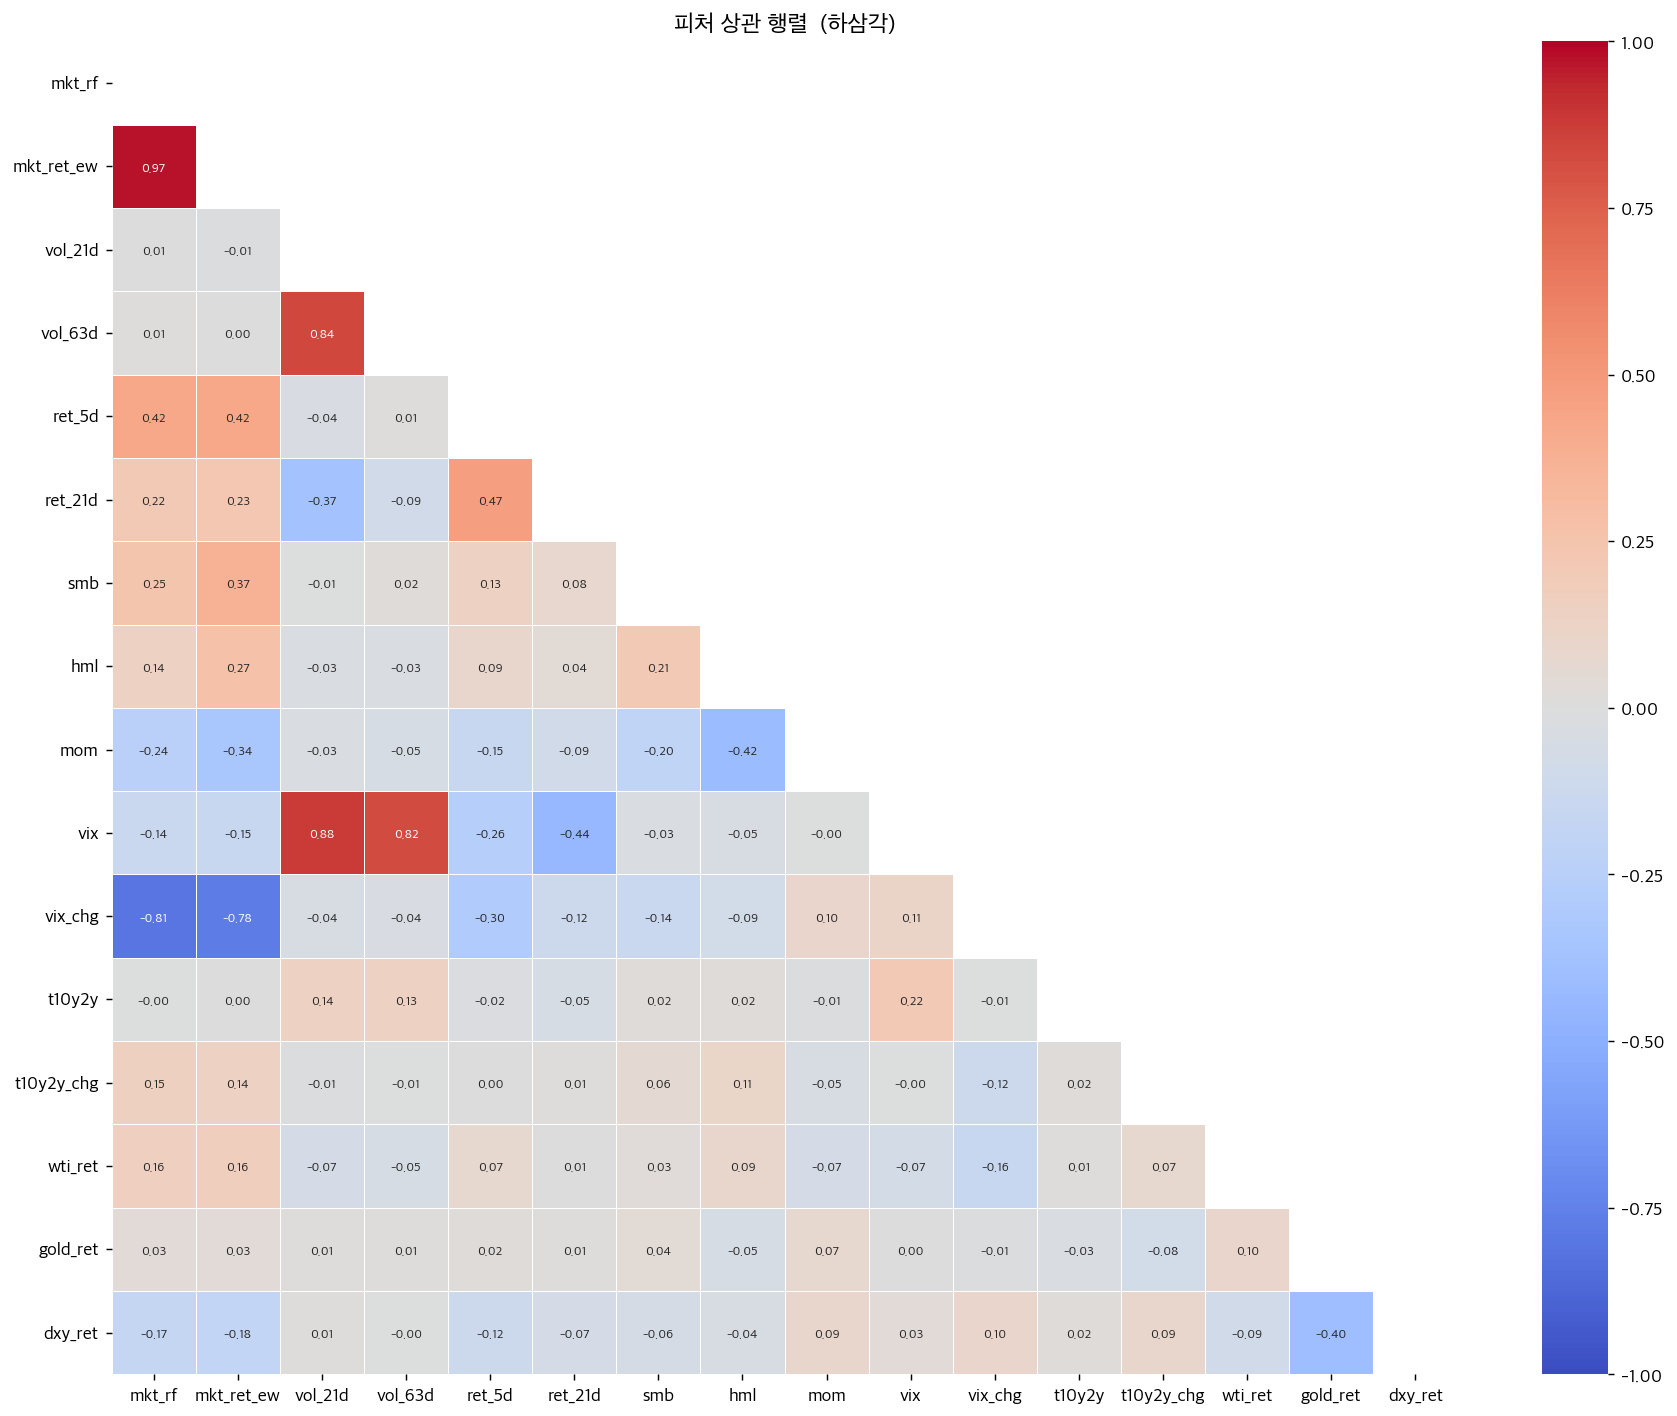

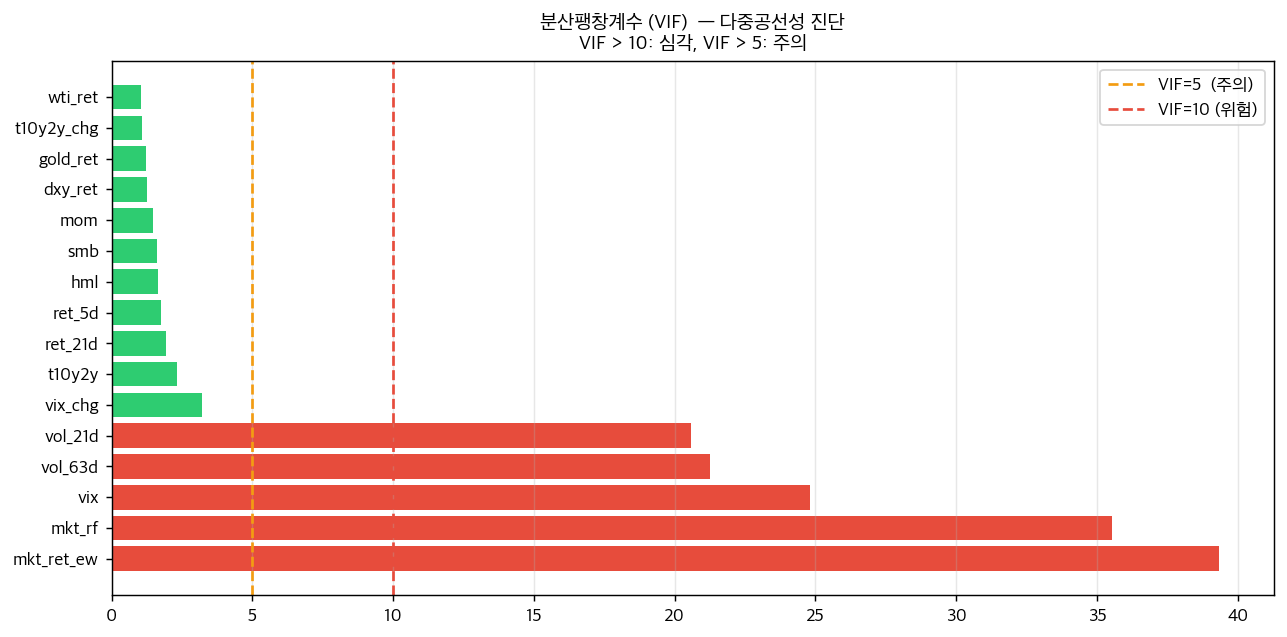

   feature       VIF
mkt_ret_ew 39.317858
    mkt_rf 35.534495
       vix 24.803775
   vol_63d 21.240896
   vol_21d 20.591166
   vix_chg  3.229354
    t10y2y  2.317764
   ret_21d  1.935560
    ret_5d  1.769343
       hml  1.655718
       smb  1.605230
       mom  1.461675
   dxy_ret  1.257084
  gold_ret  1.226469
t10y2y_chg  1.069639
   wti_ret  1.061853


In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 상관 행렬 ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr = feat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.3, ax=ax, annot_kws={"size": 7},
            vmin=-1, vmax=1)
ax.set_title("피처 상관 행렬  (하삼각)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "V1_correlation_matrix.png", bbox_inches="tight")
plt.show()

# ── VIF ──────────────────────────────────────────────────────────────────────
vif_vals = [variance_inflation_factor(feat_df.values, i)
            for i in range(feat_df.shape[1])]
vif_df = (pd.DataFrame({"feature": feat_df.columns, "VIF": vif_vals})
            .sort_values("VIF", ascending=False)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
vcolors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#2ecc71"
           for v in vif_df["VIF"]]
ax.barh(vif_df["feature"], vif_df["VIF"], color=vcolors)
ax.axvline(5,  color="#f39c12", linestyle="--", lw=1.5, label="VIF=5  (주의)")
ax.axvline(10, color="#e74c3c", linestyle="--", lw=1.5, label="VIF=10 (위험)")
ax.set_title("분산팽창계수 (VIF)  — 다중공선성 진단\nVIF > 10: 심각, VIF > 5: 주의",
             fontweight="bold", fontsize=11)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "V2_vif.png", bbox_inches="tight")
plt.show()

print(vif_df.to_string(index=False))

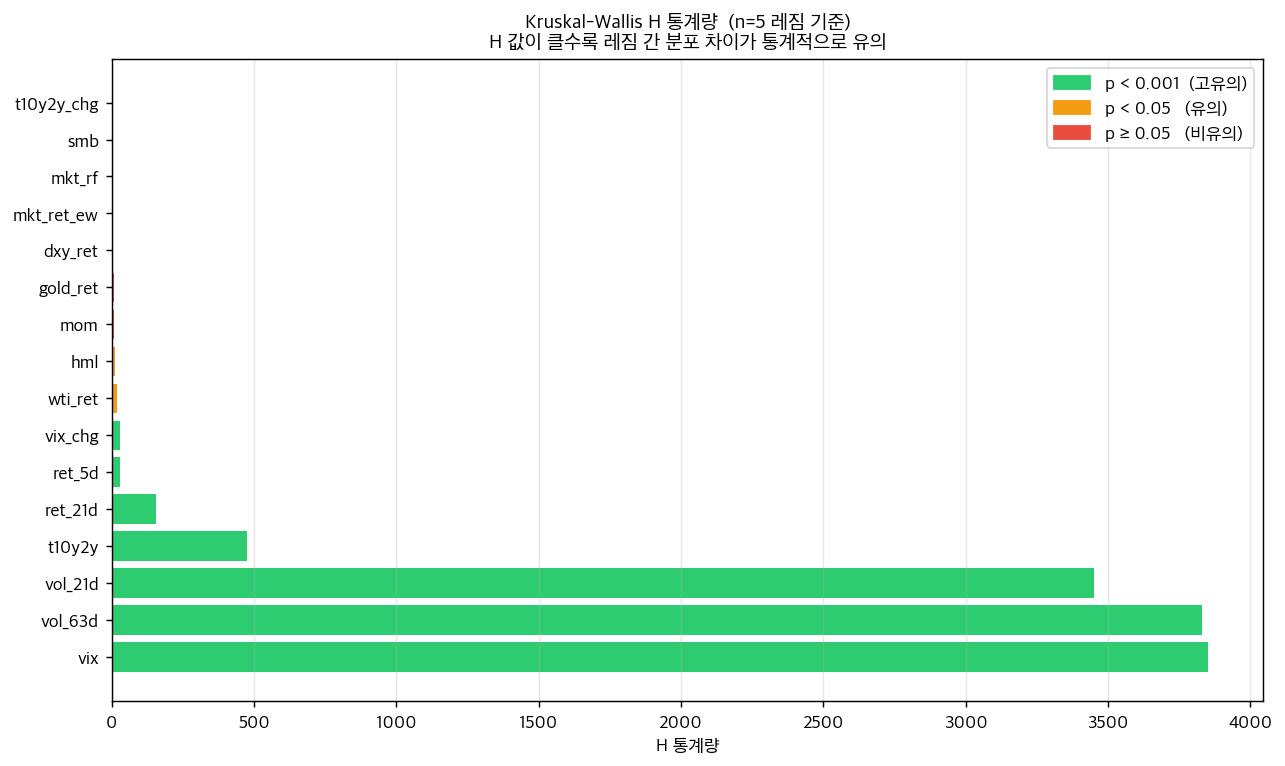

   feature    H_stat   p_KW    F_stat  p_ANOVA 유의
       vix 3852.8742 0.0000 3258.6313   0.0000  ✅
   vol_63d 3829.6782 0.0000 3013.7176   0.0000  ✅
   vol_21d 3452.3865 0.0000 2408.9876   0.0000  ✅
    t10y2y  474.7439 0.0000  145.0678   0.0000  ✅
   ret_21d  156.9335 0.0000   94.9206   0.0000  ✅
    ret_5d   29.7526 0.0000   24.0005   0.0000  ✅
   vix_chg   28.5143 0.0000    6.6174   0.0000  ✅
   wti_ret   17.8549 0.0013 2438.9395   0.0000  ✅
       hml   12.3544 0.0149    1.2590   0.2837  ✅
       mom    7.5299 0.1104    5.4729   0.0002  ❌
  gold_ret    7.1317 0.1291    0.9786   0.4178  ❌
   dxy_ret    6.5534 0.1615    1.5087   0.1967  ❌
mkt_ret_ew    6.5017 0.1647    6.8291   0.0000  ❌
    mkt_rf    6.2497 0.1813    4.3073   0.0018  ❌
       smb    6.1203 0.1903    0.7625   0.5496  ❌
t10y2y_chg    3.3803 0.4963    1.8106   0.1238  ❌


In [65]:
from scipy import stats as sp_stats

# best_n 모델의 레짐 레이블
regime_labels = np.array([results[best_n]["state_to_label"][s]
                           for s in results[best_n]["states"]])
feat_labeled  = feat_df.copy()
feat_labeled["regime"] = regime_labels

# ── Kruskal-Wallis + One-way ANOVA ───────────────────────────────────────────
kw_results = []
for col in feat_df.columns:
    groups   = [g[col].values for _, g in feat_labeled.groupby("regime")]
    f_stat, p_anova = sp_stats.f_oneway(*groups)
    h_stat, p_kw    = sp_stats.kruskal(*groups)
    kw_results.append({
        "feature": col,
        "H_stat" : h_stat, "p_KW"  : p_kw,
        "F_stat" : f_stat, "p_ANOVA": p_anova,
        "유의"   : "✅" if p_kw < 0.05 else "❌",
    })

kw_df = (pd.DataFrame(kw_results)
           .sort_values("H_stat", ascending=False)
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#2ecc71" if p < 0.001 else "#f39c12" if p < 0.05 else "#e74c3c"
              for p in kw_df["p_KW"]]
ax.barh(kw_df["feature"], kw_df["H_stat"], color=bar_colors)
ax.set_title(f"Kruskal-Wallis H 통계량  (n={best_n} 레짐 기준)\n"
             "H 값이 클수록 레짐 간 분포 차이가 통계적으로 유의",
             fontweight="bold", fontsize=11)
ax.set_xlabel("H 통계량")
ax.grid(axis="x", alpha=0.3)
p1 = mpatches.Patch(color="#2ecc71", label="p < 0.001  (고유의)")
p2 = mpatches.Patch(color="#f39c12", label="p < 0.05   (유의)")
p3 = mpatches.Patch(color="#e74c3c", label="p ≥ 0.05   (비유의)")
ax.legend(handles=[p1, p2, p3])
plt.tight_layout()
plt.savefig(OUT_DIR / "V3_kruskal_wallis.png", bbox_inches="tight")
plt.show()

print(kw_df[["feature","H_stat","p_KW","F_stat","p_ANOVA","유의"]]
      .round(4).to_string(index=False))

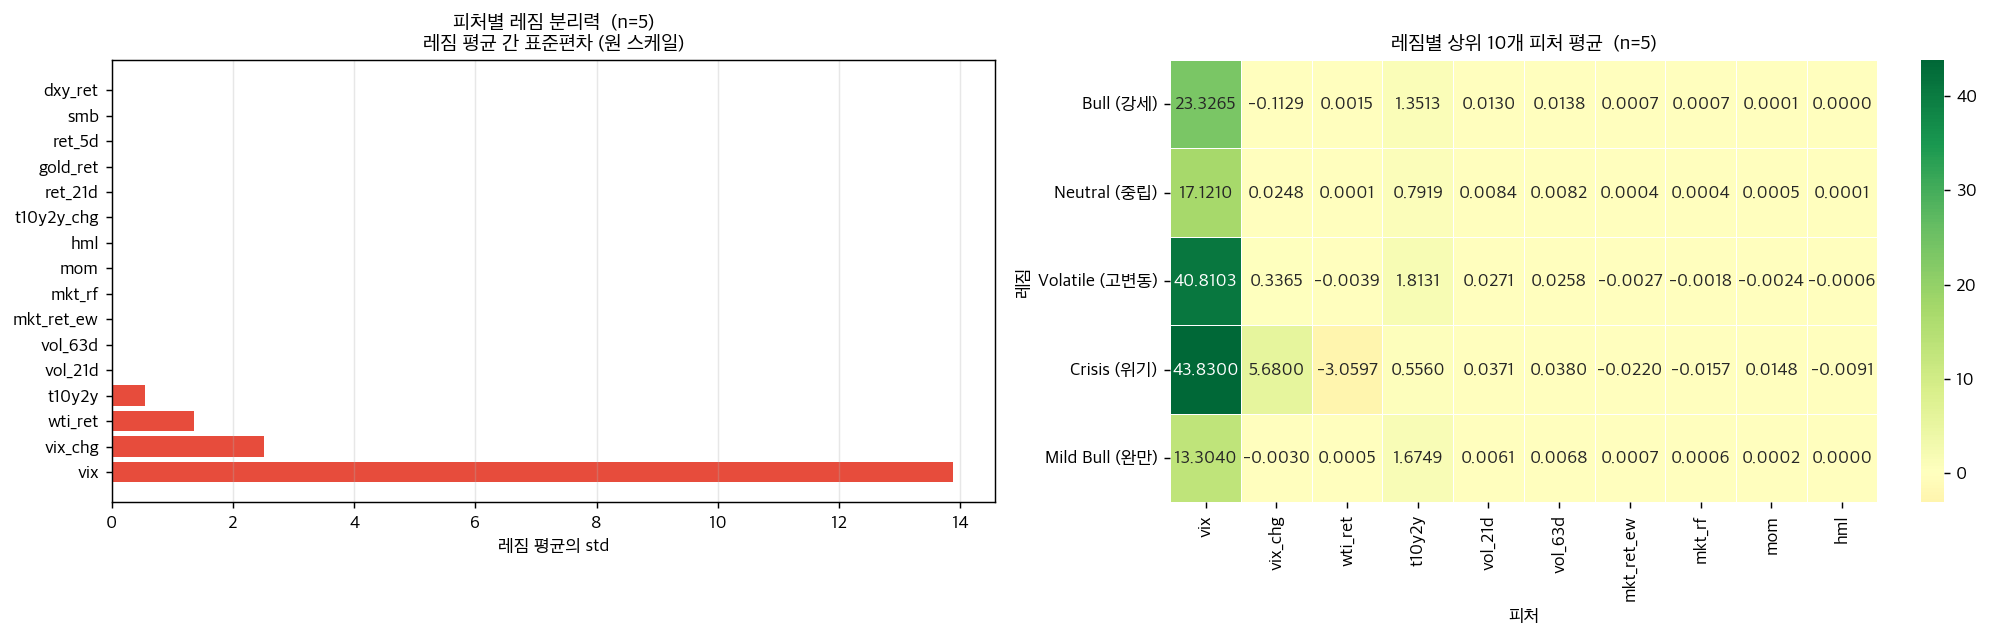


레짐 분리력 순위:
   1. vix              std=13.87753  🔴 HIGH
   2. vix_chg          std=2.51828  🔴 HIGH
   3. wti_ret          std=1.36812  🔴 HIGH
   4. t10y2y           std=0.54742  🔴 HIGH
   5. vol_21d          std=0.01327  🟡 MID 
   6. vol_63d          std=0.01320  🟡 MID 
   7. mkt_ret_ew       std=0.00984  🟡 MID 
   8. mkt_rf           std=0.00709  🟡 MID 
   9. mom              std=0.00689  🔵 LOW 
  10. hml              std=0.00403  🔵 LOW 
  11. t10y2y_chg       std=0.00399  🔵 LOW 
  12. ret_21d          std=0.00387  🔵 LOW 
  13. gold_ret         std=0.00314  🔵 LOW 
  14. ret_5d           std=0.00262  🔵 LOW 
  15. smb              std=0.00168  🔵 LOW 
  16. dxy_ret          std=0.00079  🔵 LOW 


In [66]:
# ── HMM 평균 벡터 기반 피처 중요도 ──────────────────────────────────────────
best_model = results[best_n]["model"]
means_orig = scaler.inverse_transform(best_model.means_)
means_df   = pd.DataFrame(
    means_orig,
    columns=feat_df.columns,
    index=[results[best_n]["state_to_label"][i] for i in range(best_n)]
)

# 레짐 간 평균의 표준편차 → 피처별 분리력
importance = means_df.std(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_imp = ["#e74c3c" if v >= importance.quantile(0.75)
              else "#f39c12" if v >= importance.quantile(0.5)
              else "#3498db" for v in importance]
axes[0].barh(importance.index, importance.values, color=colors_imp)
axes[0].set_title(f"피처별 레짐 분리력  (n={best_n})\n레짐 평균 간 표준편차 (원 스케일)",
                  fontweight="bold", fontsize=11)
axes[0].set_xlabel("레짐 평균의 std")
axes[0].grid(axis="x", alpha=0.3)

top10 = importance.index[:10].tolist()
sns.heatmap(means_df[top10], annot=True, fmt=".4f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title(f"레짐별 상위 10개 피처 평균  (n={best_n})", fontweight="bold", fontsize=11)
axes[1].set_xlabel("피처"); axes[1].set_ylabel("레짐")

plt.tight_layout()
plt.savefig(OUT_DIR / "V4_feature_importance.png", bbox_inches="tight")
plt.show()

print("\n레짐 분리력 순위:")
for rank, (feat_name, val) in enumerate(importance.items(), 1):
    tier = "🔴 HIGH" if val >= importance.quantile(0.75) else \
           "🟡 MID " if val >= importance.quantile(0.5) else "🔵 LOW "
    print(f"  {rank:>2}. {feat_name:<15}  std={val:.5f}  {tier}")

기준 BIC (전체 16개 피처, n=5): 782517933.8

피처                                제거 후 BIC            ΔBIC  기여도
--------------------------------------------------------------------
  mkt_rf                       795372015.6     +12854081.8  🔴 핵심
  mkt_ret_ew                   817569237.9     +35051304.1  🔴 핵심
  vol_21d                      776535618.4      -5982315.4  🔵 미미
  vol_63d                      761076034.8     -21441899.0  🔵 미미
  ret_5d                       727175528.1     -55342405.7  🔵 미미
  ret_21d                      713949742.1     -68568191.7  🔵 미미
  smb                          716519725.1     -65998208.7  🔵 미미
  hml                          722837520.1     -59680413.7  🔵 미미
  mom                          699152164.5     -83365769.3  🔵 미미
  vix                          774635564.5      -7882369.3  🔵 미미
  vix_chg                      752736085.5     -29781848.3  🔵 미미
  t10y2y                       704166610.5     -78351323.3  🔵 미미
  t10y2y_chg                   698124779.3     -8

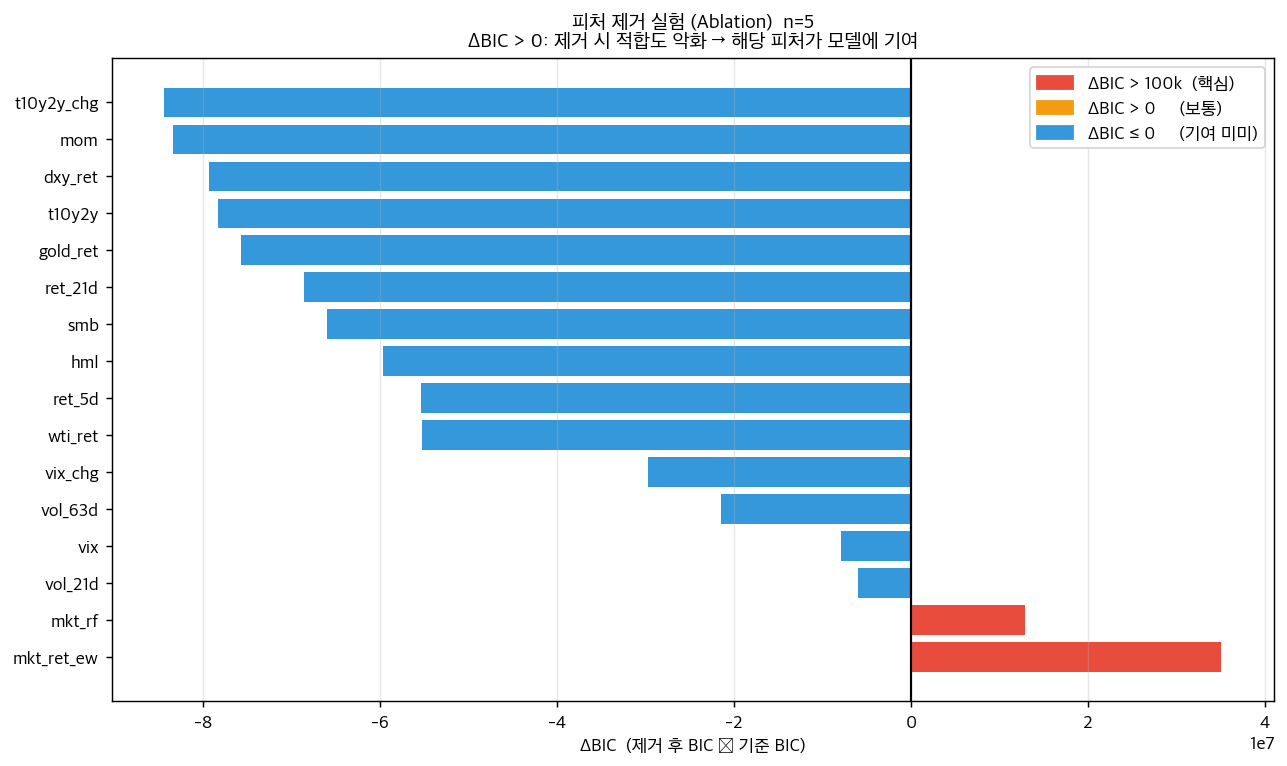

In [67]:
# ── Ablation: 피처 하나씩 제거 시 BIC 변화 ───────────────────────────────────
base_bic = results[best_n]["bic"]
ablation_results = []

print(f"기준 BIC (전체 {feat_df.shape[1]}개 피처, n={best_n}): {base_bic:.1f}\n")
print(f"{'피처':<18}  {'제거 후 BIC':>22}  {'ΔBIC':>14}  기여도")
print("-" * 68)

for col in feat_df.columns:
    cols_sub = [c for c in feat_df.columns if c != col]
    X_sub    = StandardScaler().fit_transform(feat_df[cols_sub].values)
    m_abl    = GaussianHMM(n_components=best_n, covariance_type="full",
                           n_iter=200, random_state=SEED)
    m_abl.fit(X_sub)
    bic_sub  = -2 * m_abl.score(X_sub) * len(X_sub) + best_n * np.log(len(X_sub))
    delta    = bic_sub - base_bic
    tier     = "🔴 핵심" if delta > 1e5 else "🟡 보통" if delta > 0 else "🔵 미미"
    ablation_results.append({"feature": col, "BIC_without": bic_sub, "delta_BIC": delta})
    print(f"  {col:<16}  {bic_sub:>22.1f}  {delta:>+14.1f}  {tier}")

abl_df = (pd.DataFrame(ablation_results)
            .sort_values("delta_BIC", ascending=False)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if d > 1e5 else "#f39c12" if d > 0 else "#3498db"
          for d in abl_df["delta_BIC"]]
ax.barh(abl_df["feature"], abl_df["delta_BIC"], color=colors)
ax.axvline(0, color="black", lw=1.2)
ax.set_title(f"피처 제거 실험 (Ablation)  n={best_n}\n"
             "ΔBIC > 0: 제거 시 적합도 악화 → 해당 피처가 모델에 기여",
             fontweight="bold", fontsize=11)
ax.set_xlabel("ΔBIC  (제거 후 BIC − 기준 BIC)")
p1 = mpatches.Patch(color="#e74c3c", label="ΔBIC > 100k  (핵심)")
p2 = mpatches.Patch(color="#f39c12", label="ΔBIC > 0     (보통)")
p3 = mpatches.Patch(color="#3498db", label="ΔBIC ≤ 0     (기여 미미)")
ax.legend(handles=[p1, p2, p3]); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "V5_ablation.png", bbox_inches="tight")
plt.show()

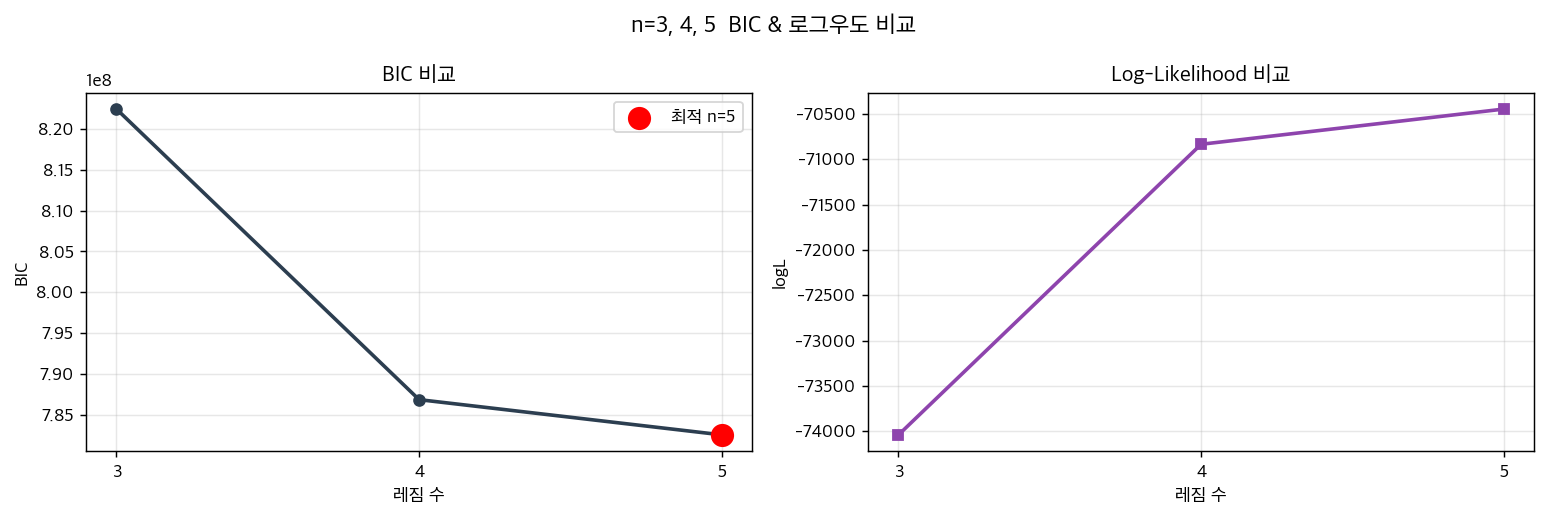

In [68]:
ns   = [3, 4, 5]
bics = [results[n]["bic"]  for n in ns]
lgls = [results[n]["logL"] for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ns, bics, marker="o", color="#2c3e50", lw=2)
axes[0].scatter([best_n], [results[best_n]["bic"]], color="red", s=140, zorder=5,
                label=f"최적 n={best_n}")
axes[0].set_title("BIC 비교", fontweight="bold", fontsize=12)
axes[0].set_xlabel("레짐 수"); axes[0].set_ylabel("BIC")
axes[0].set_xticks(ns); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ns, lgls, marker="s", color="#8e44ad", lw=2)
axes[1].set_title("Log-Likelihood 비교", fontweight="bold", fontsize=12)
axes[1].set_xlabel("레짐 수"); axes[1].set_ylabel("logL")
axes[1].set_xticks(ns); axes[1].grid(alpha=0.3)

plt.suptitle("n=3, 4, 5  BIC & 로그우도 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_bic_comparison.png", bbox_inches="tight")
plt.show()

## 6. 타임라인 비교 (n=3, 4, 5)

레짐 수별로 시장 국면이 어떻게 구분되는지 누적 수익률 위에 겹쳐 비교합니다.

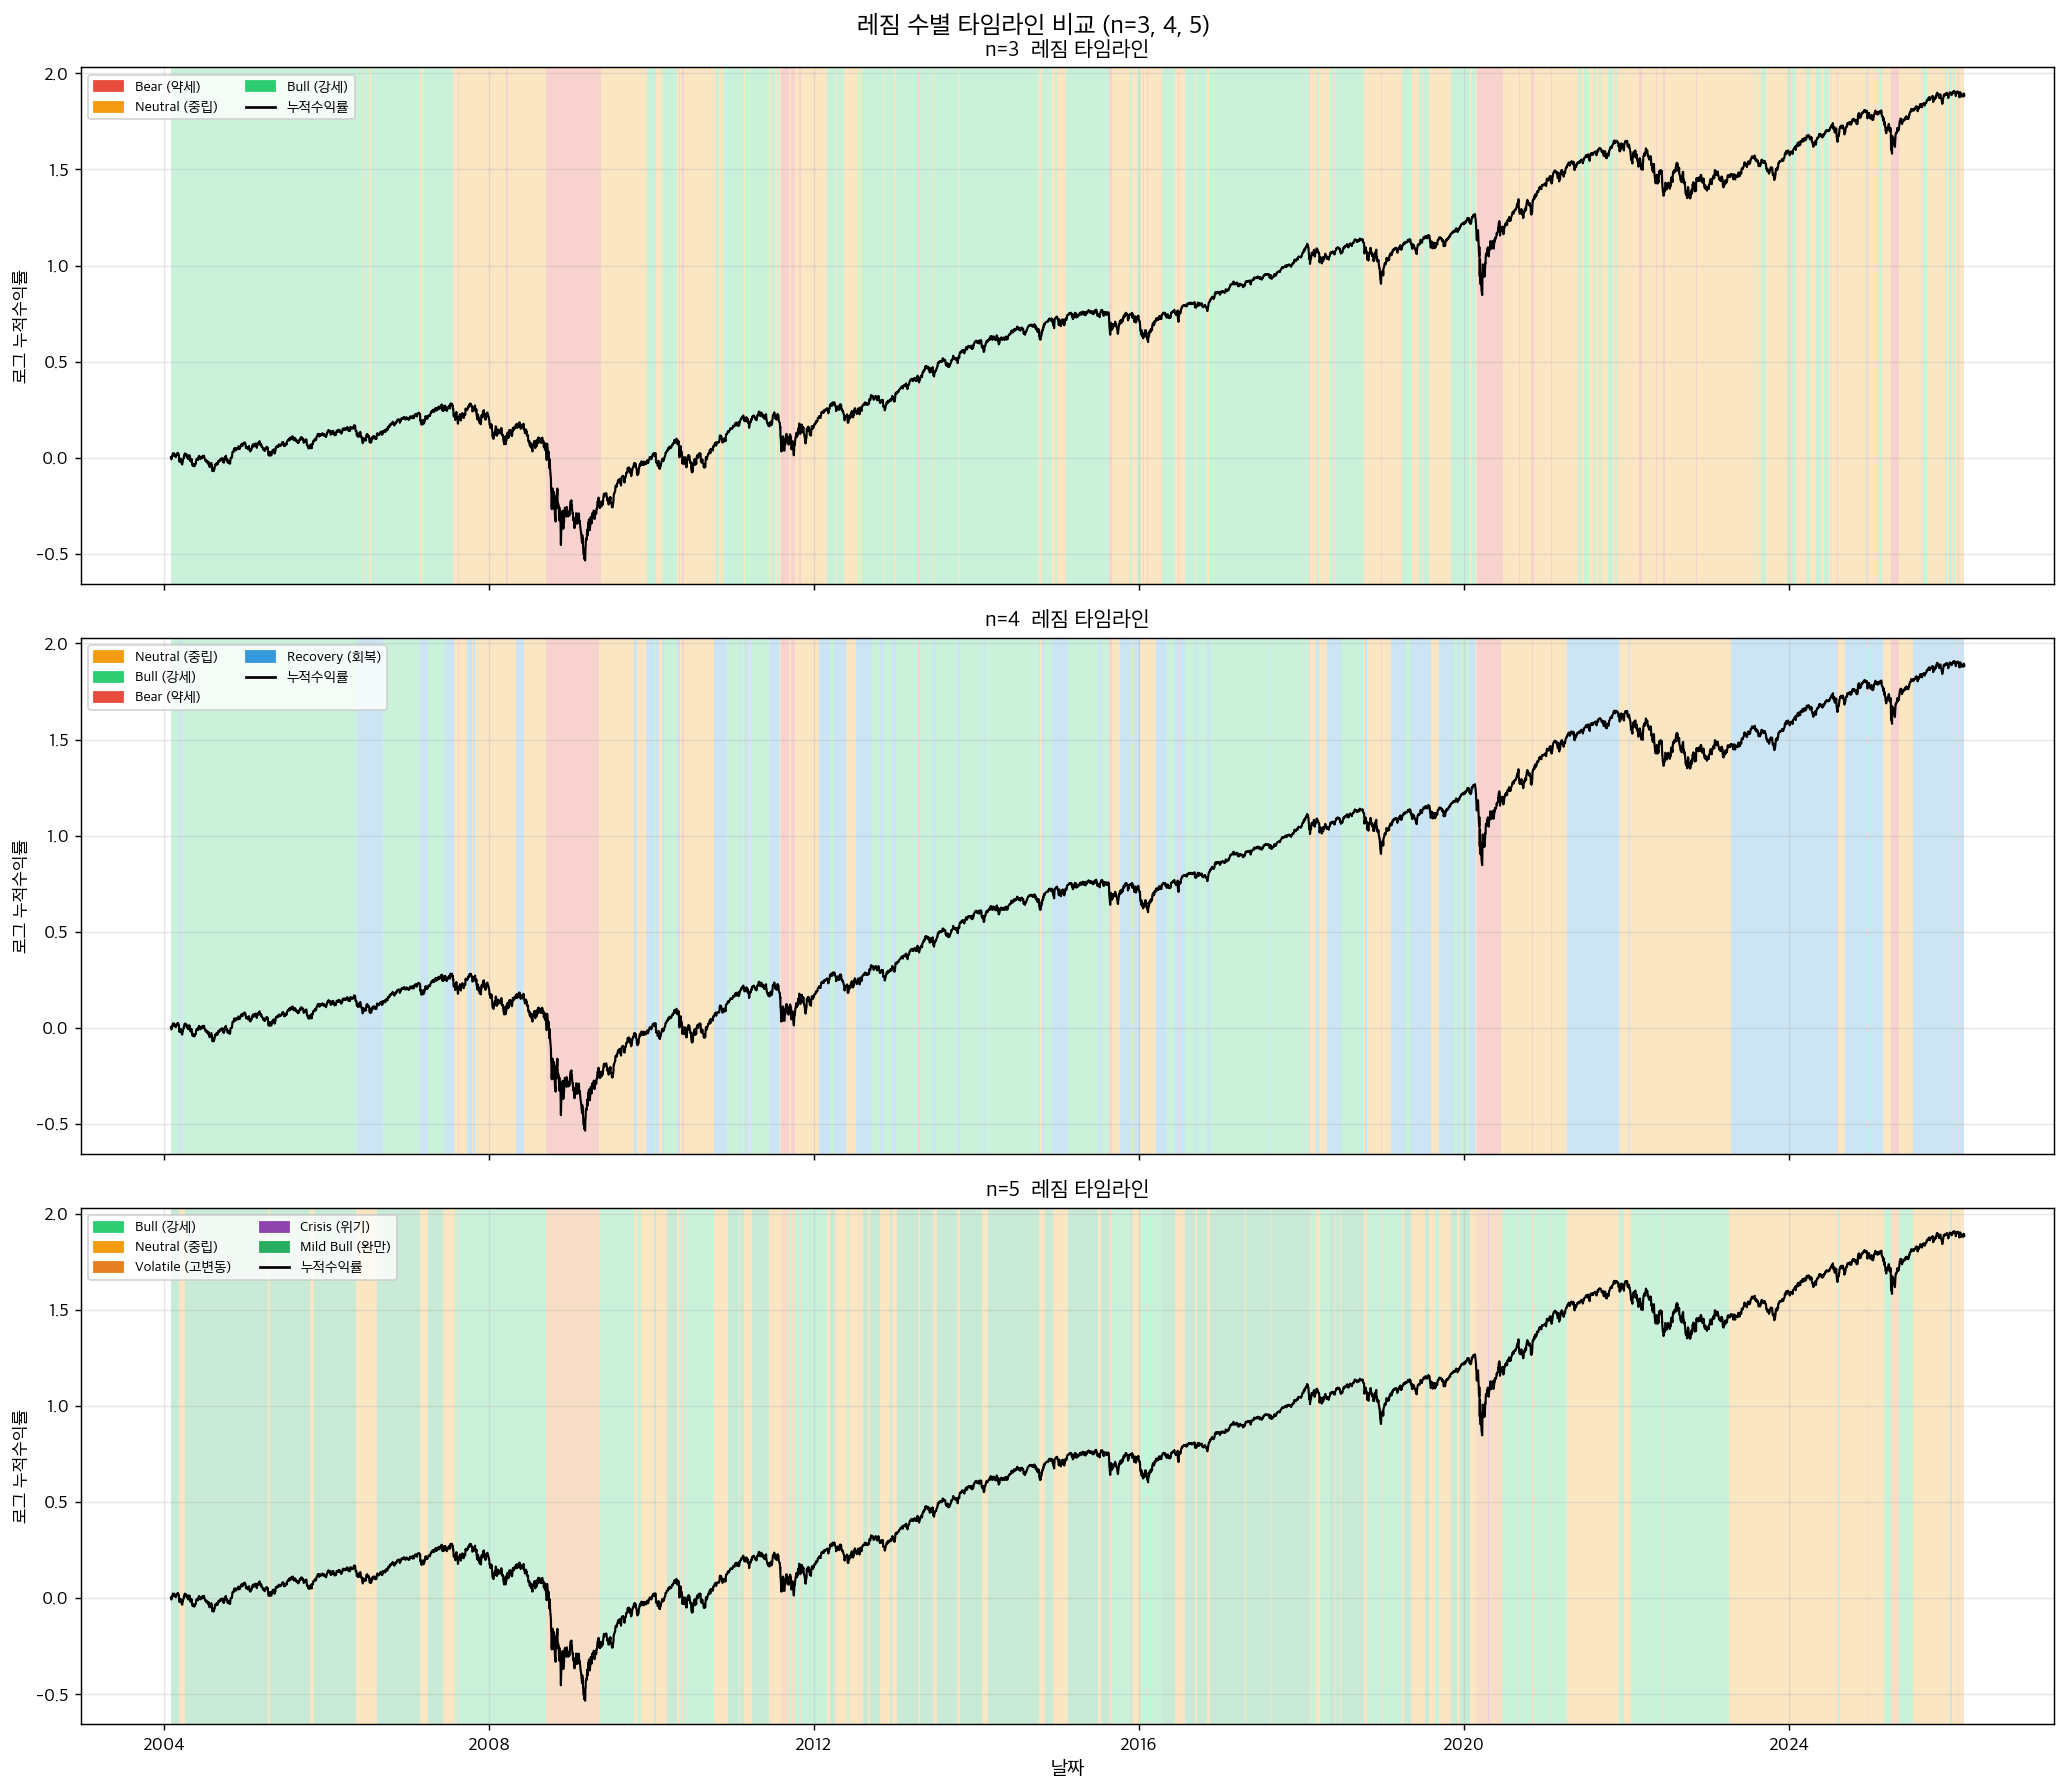

In [69]:
mkt_cum = (1 + feat_df["mkt_rf"]).cumprod().apply(np.log)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, n in zip(axes, [3, 4, 5]):
    r   = results[n]
    st  = r["states"]
    s2l = r["state_to_label"]
    uq  = sorted(s2l.keys())

    ax.plot(dates, mkt_cum.values, color="black", lw=1.2)

    prev_s = st[0]; t0 = dates[0]
    for i in range(1, len(st)):
        if st[i] != prev_s or i == len(st) - 1:
            lbl = s2l[prev_s]
            ax.axvspan(t0, dates[i], alpha=0.25, color=get_color(lbl, uq.index(prev_s)), lw=0)
            prev_s = st[i]; t0 = dates[i]

    patches = [mpatches.Patch(color=get_color(s2l[s], uq.index(s)), label=s2l[s]) for s in uq]
    ax.legend(handles=patches + [plt.Line2D([0],[0], color="black", lw=1.5, label="누적수익률")],
              loc="upper left", fontsize=8, ncol=2)
    ax.set_ylabel("로그 누적수익률")
    ax.set_title(f"n={n}  레짐 타임라인", fontweight="bold", fontsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("날짜", fontsize=11)
plt.suptitle("레짐 수별 타임라인 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_timeline_comparison.png", bbox_inches="tight")
plt.show()

## 7. 레짐 통계 비교 (n=3, 4, 5)

In [70]:
print("=" * 72)
print("   레짐 수별 통계 비교")
print("=" * 72)
print(f"분석 기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}   총 거래일: {len(feat_df):,}일\n")

for n in [3, 4, 5]:
    r = results[n]
    mark = " ◀ BIC 최적" if n == best_n else ""
    print(f"── n={n}  (BIC={r['bic']:.0f},  logL={r['logL']:.2f},  수렴={r['model'].monitor_.converged}){mark}")
    for _, row in r["stats"].iterrows():
        print(f"  [{row['label']:<16}]  {row['pct']:5.1f}%  ({int(row['count']):4d}일)  "
              f"수익={row['mean_ret']*100:+.3f}%  "
              f"변동={row['mean_vol']*100:.3f}%  "
              f"VIX={row['mean_vix']:.1f}")
    print()

   레짐 수별 통계 비교
분석 기간: 2004-02-02 ~ 2026-02-27   총 거래일: 5,554일

── n=3  (BIC=822447905,  logL=-74041.04,  수렴=True)
  [Bull (강세)       ]   48.3%  (2685일)  수익=+0.075%  변동=0.660%  VIX=14.0
  [Neutral (중립)    ]   44.4%  (2464일)  수익=+0.025%  변동=1.107%  VIX=20.9
  [Bear (약세)       ]    7.3%  ( 405일)  수익=-0.089%  변동=2.663%  VIX=40.2

── n=4  (BIC=786832518,  logL=-70834.76,  수렴=True)
  [Bull (강세)       ]   36.3%  (2018일)  수익=+0.076%  변동=0.622%  VIX=13.4
  [Recovery (회복)   ]   31.3%  (1739일)  수익=+0.041%  변동=0.796%  VIX=16.7
  [Neutral (중립)    ]   26.1%  (1452일)  수익=+0.021%  변동=1.351%  VIX=24.0
  [Bear (약세)       ]    6.2%  ( 345일)  수익=-0.078%  변동=2.839%  VIX=42.0

── n=5  (BIC=782517934,  logL=-70446.34,  수렴=True) ◀ BIC 최적
  [Bull (강세)       ]   26.3%  (1461일)  수익=+0.075%  변동=1.302%  VIX=23.4
  [Mild Bull (완만)  ]   36.7%  (2041일)  수익=+0.060%  변동=0.608%  VIX=13.3
  [Neutral (중립)    ]   30.2%  (1676일)  수익=+0.041%  변동=0.843%  VIX=17.1
  [Volatile (고변동)  ]    6.8%  ( 375일)  수익=-0.189%  변동=2.722%  V

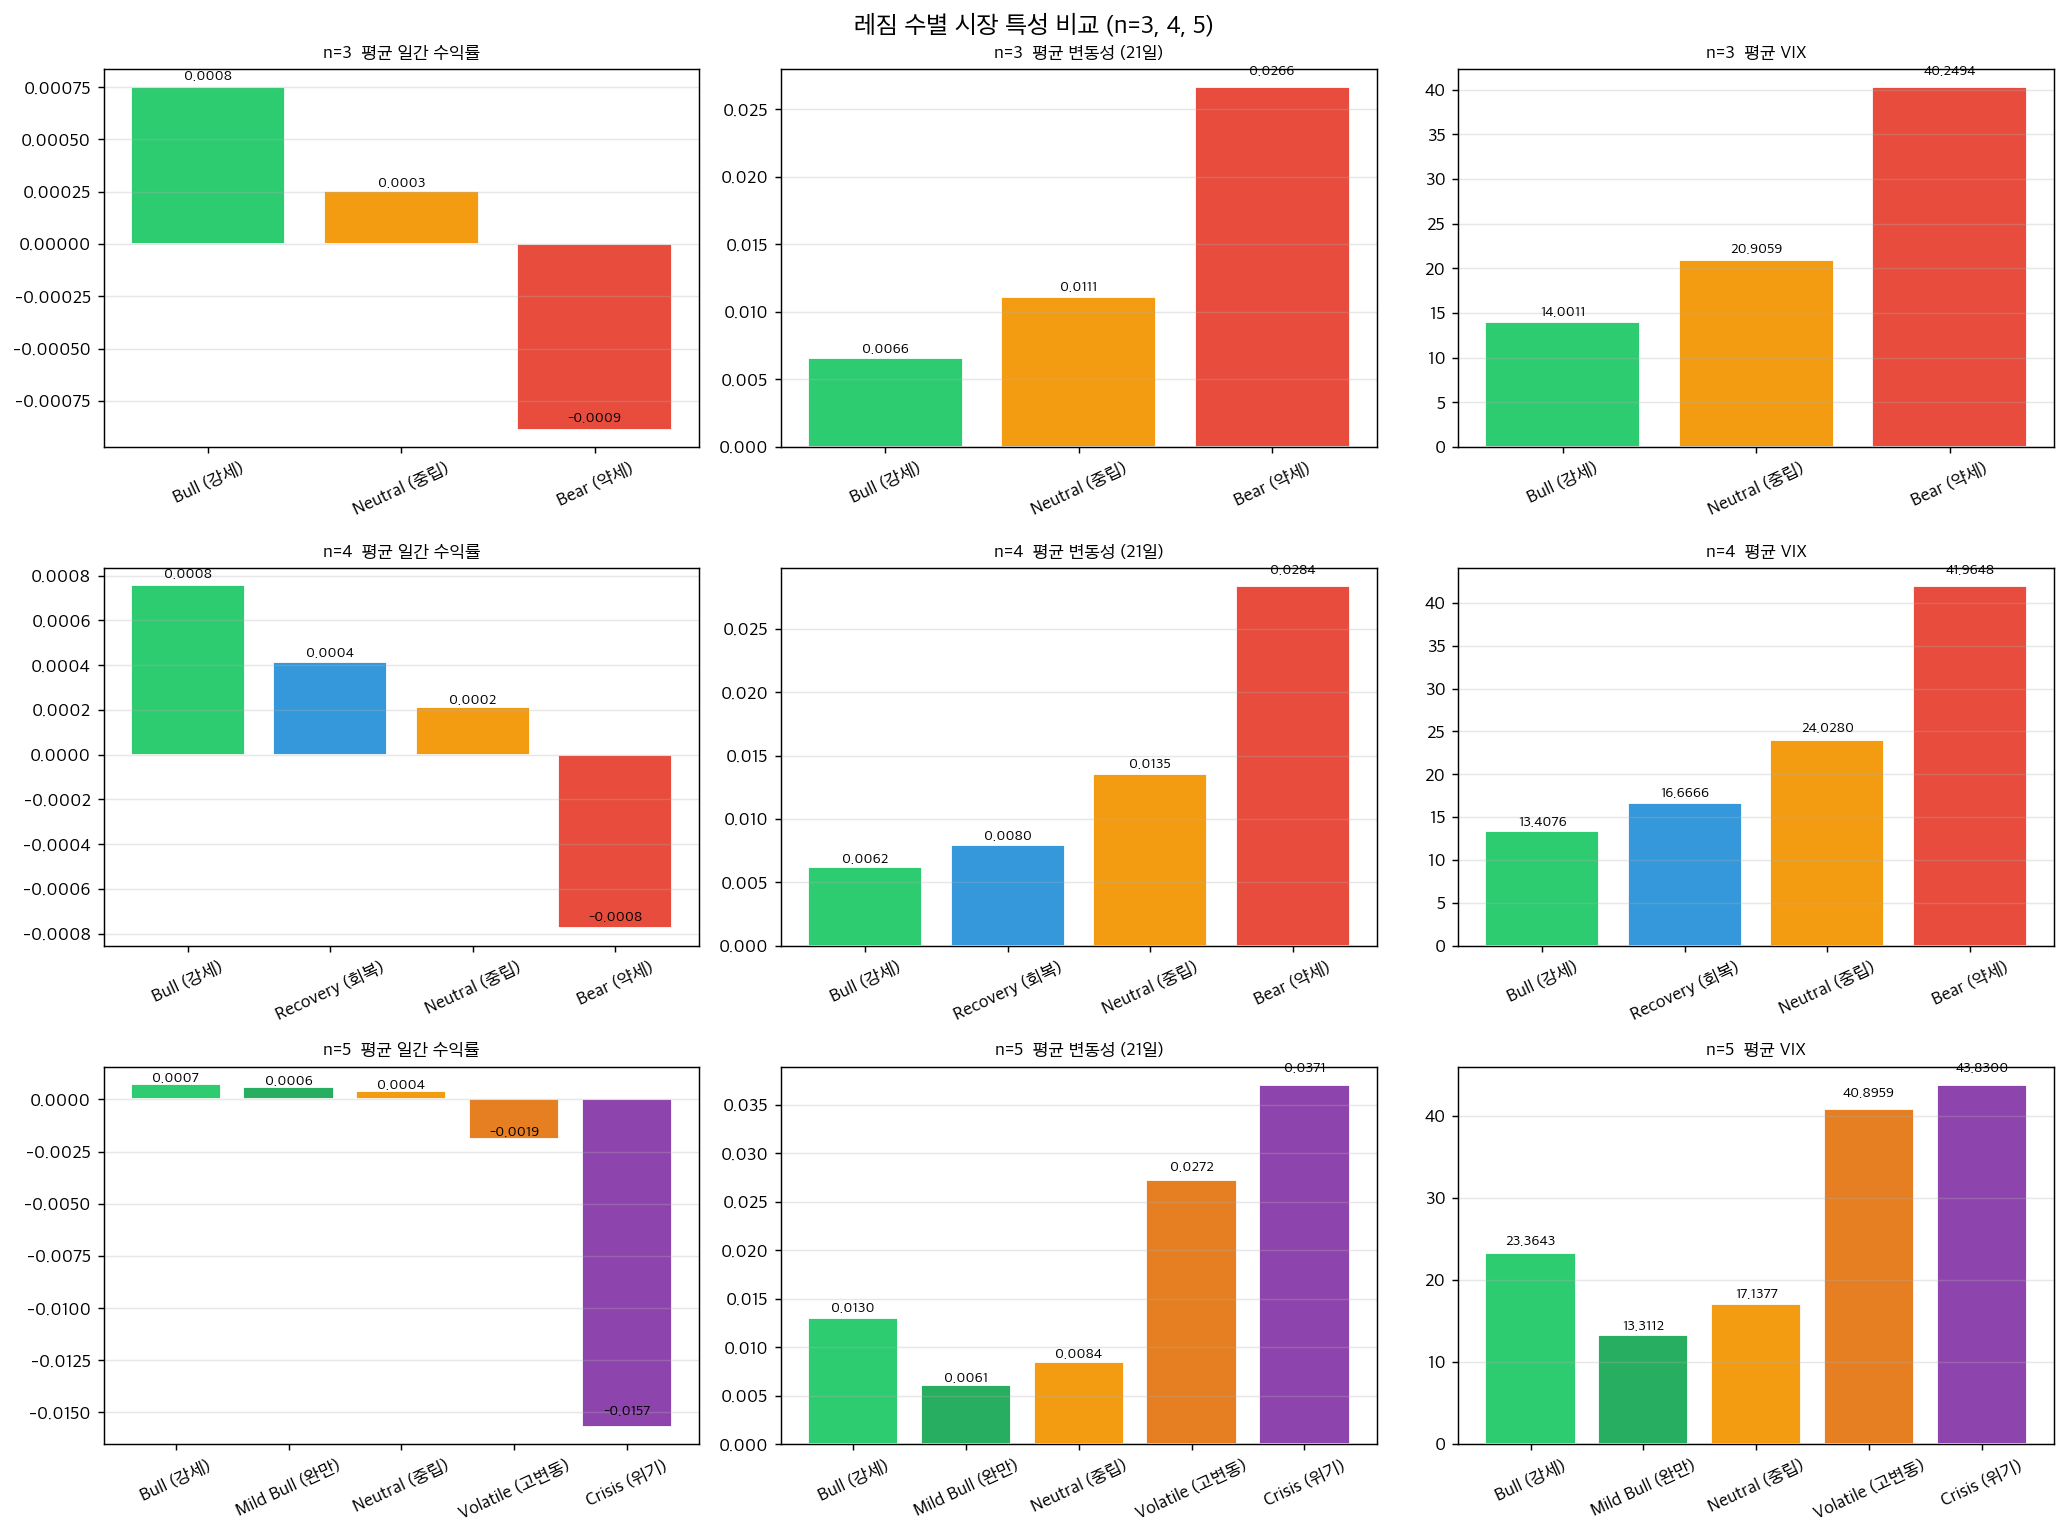

In [71]:
metrics = [("mean_ret", "평균 일간 수익률"), ("mean_vol", "평균 변동성 (21일)"), ("mean_vix", "평균 VIX")]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row_idx, n in enumerate([3, 4, 5]):
    r  = results[n]
    st = r["stats"]
    for col_idx, (col, title) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        colors = [get_color(row["label"], i) for i, row in st.iterrows()]
        bars   = ax.bar(st["label"], st[col], color=colors, edgecolor="white")
        ax.set_title(f"n={n}  {title}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, st[col]):
            if pd.notna(val):
                ypos = bar.get_height() + abs(bar.get_height()) * 0.03
                ax.text(bar.get_x() + bar.get_width()/2, ypos,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("레짐 수별 시장 특성 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_regime_stats_comparison.png", bbox_inches="tight")
plt.show()

## 8. 전이 행렬 비교 (n=3, 4, 5)

대각선 값이 높을수록 해당 레짐의 **지속성(persistence)**이 높습니다.

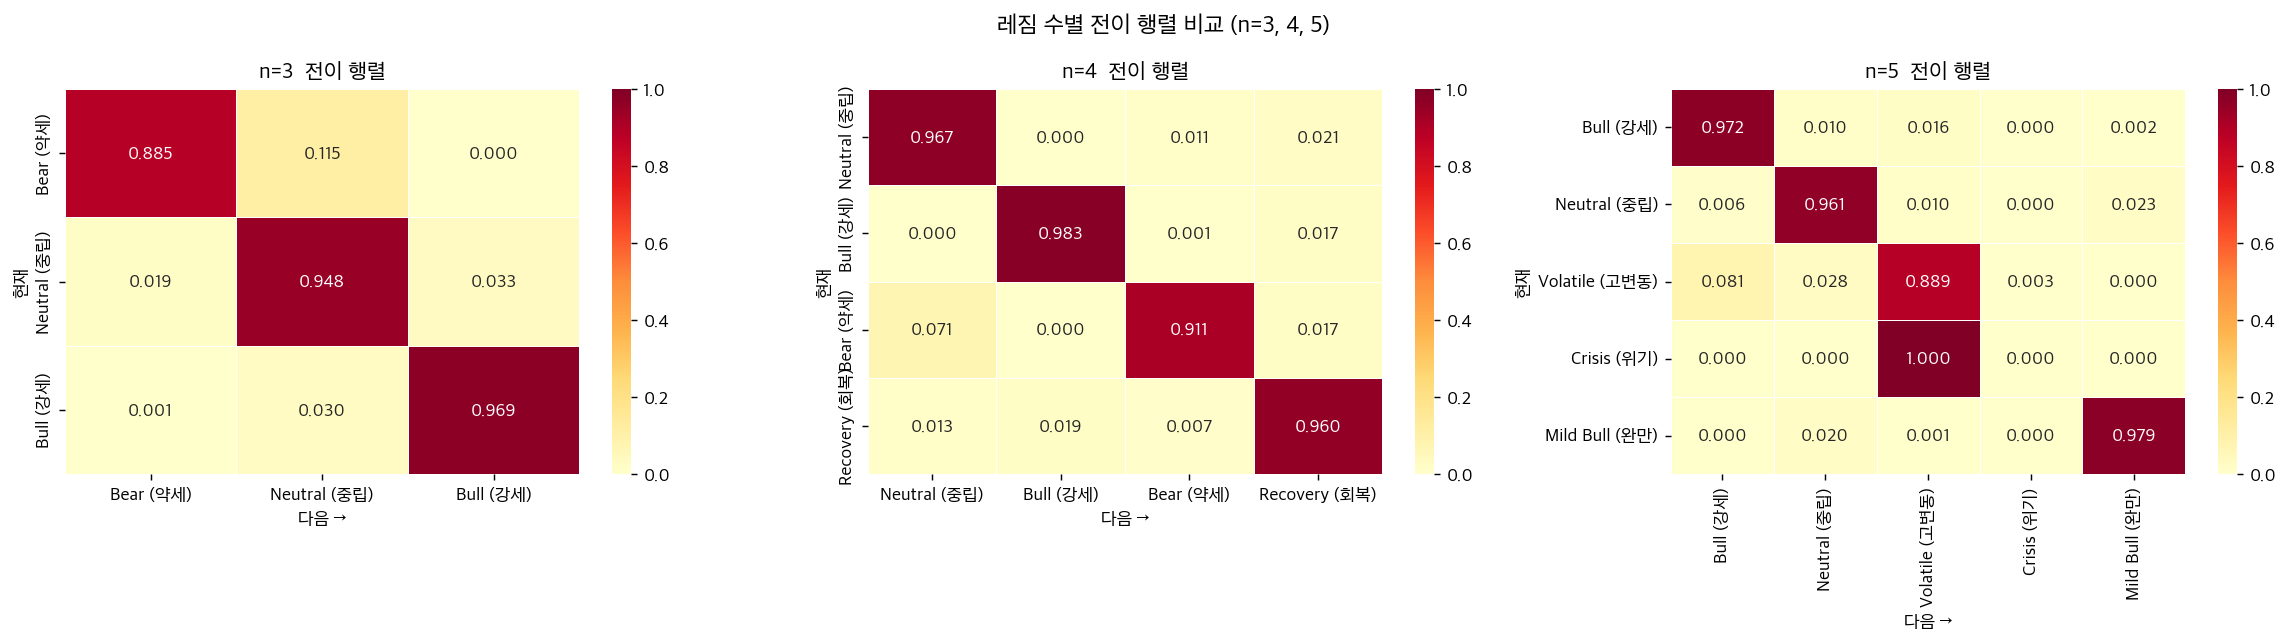

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n in zip(axes, [3, 4, 5]):
    r        = results[n]
    labels   = [r["state_to_label"][i] for i in range(n)]
    trans_df = pd.DataFrame(r["model"].transmat_, index=labels, columns=labels)
    sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"n={n}  전이 행렬", fontweight="bold", fontsize=12)
    ax.set_xlabel("다음 →"); ax.set_ylabel("현재")

plt.suptitle("레짐 수별 전이 행렬 비교 (n=3, 4, 5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_transition_comparison.png", bbox_inches="tight")
plt.show()

## 9. 피처 분포 비교 (KDE, n=3, 4, 5)

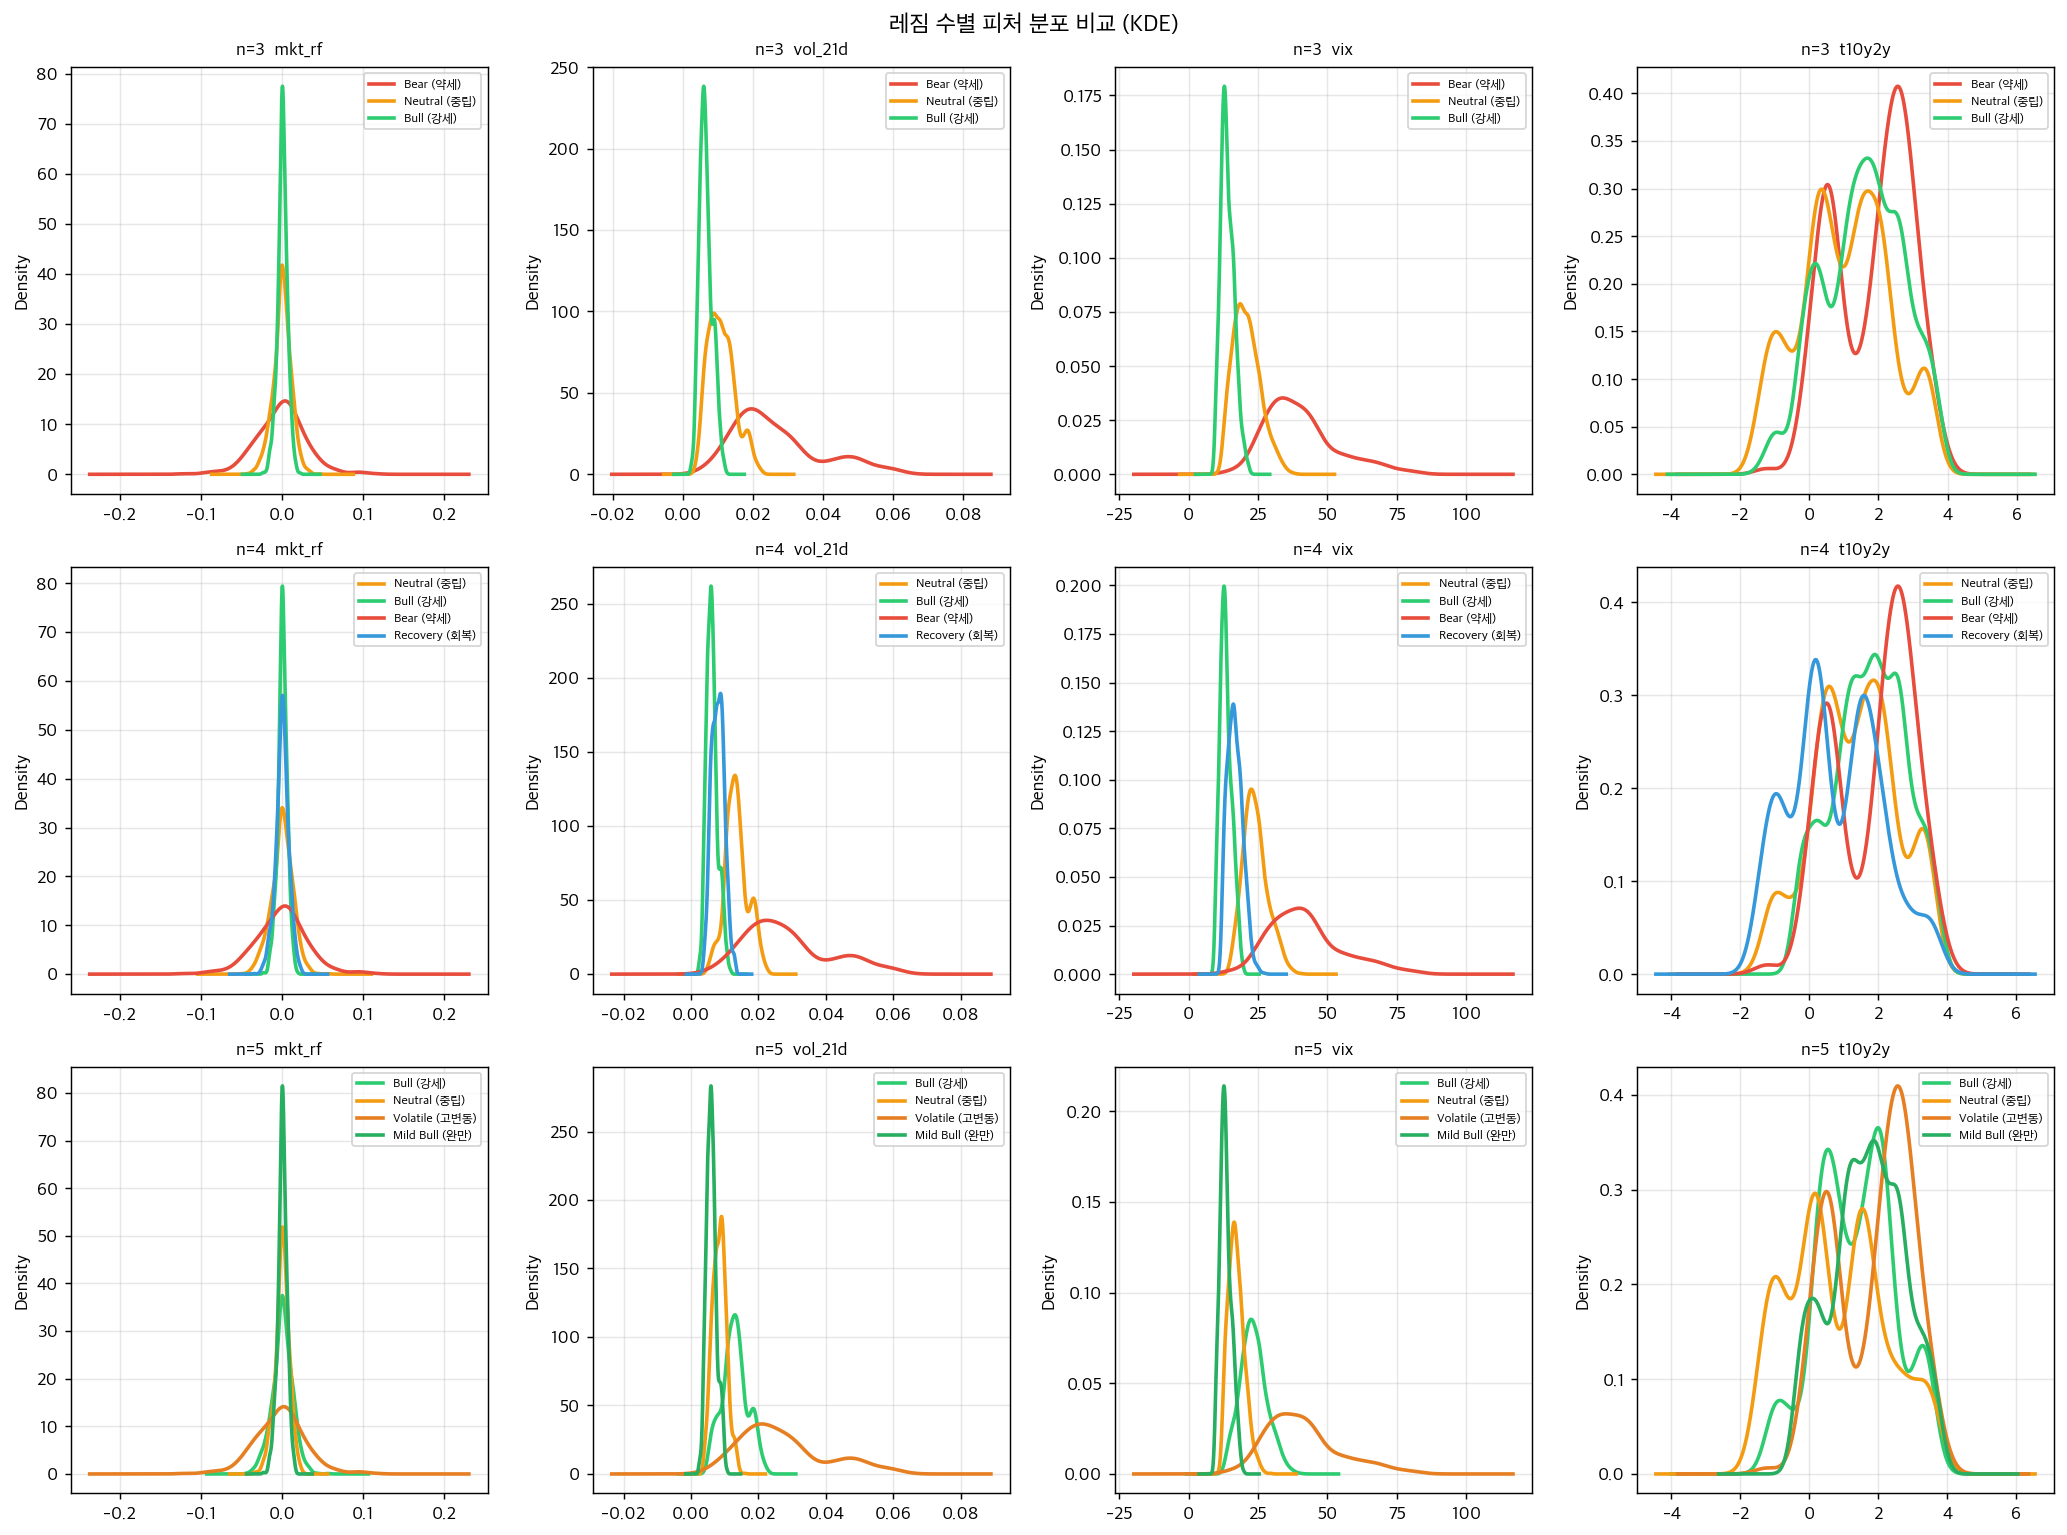

In [73]:
plot_feats = [f for f in ["mkt_rf", "vol_21d", "vix", "t10y2y"] if f in feat_df.columns]

fig, axes = plt.subplots(3, len(plot_feats), figsize=(4*len(plot_feats), 12))

for row_idx, n in enumerate([3, 4, 5]):
    r      = results[n]
    st_arr = r["states"]
    s2l    = r["state_to_label"]
    uq     = sorted(s2l.keys())
    for col_idx, fname in enumerate(plot_feats):
        ax = axes[row_idx][col_idx]
        for s in uq:
            lbl  = s2l[s]
            vals = feat_df.loc[st_arr == s, fname].dropna()
            if len(vals) < 2:
                continue
            vals.plot.kde(ax=ax, label=lbl, color=get_color(lbl, uq.index(s)), lw=2)
        ax.set_title(f"n={n}  {fname}", fontsize=10)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("레짐 수별 피처 분포 비교 (KDE)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_kde_comparison.png", bbox_inches="tight")
plt.show()

## 10. 섹터 ETF 수익률 비교 (n=3, 4, 5)

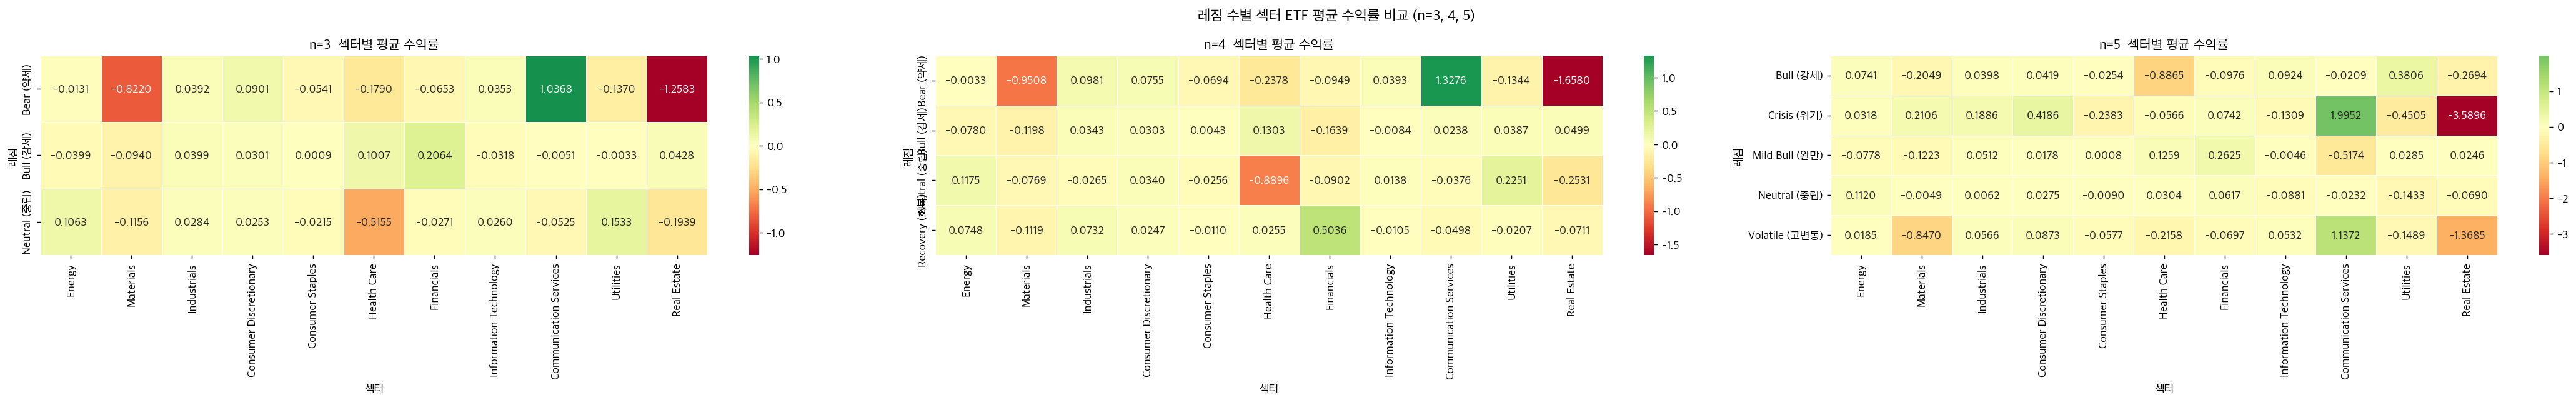

In [74]:
sector_cols = [c for c in df_raw.columns if c.endswith("_ret") and c != "mkt_ret_ew"]

if sector_cols:
    fig, axes = plt.subplots(1, 3, figsize=(max(18, len(sector_cols)*3), 5))
    for ax, n in zip(axes, [3, 4, 5]):
        r   = results[n]
        tmp = feat_df[[]].copy()
        tmp["regime"] = [r["state_to_label"][s] for s in r["states"]]
        merged = tmp.join(df_raw[sector_cols], how="left")
        sm = merged.groupby("regime")[sector_cols].mean()
        sm.columns = [c.replace("_ret", "") for c in sm.columns]
        sns.heatmap(sm, annot=True, fmt=".4f", cmap="RdYlGn",
                    center=0, linewidths=0.5, ax=ax)
        ax.set_title(f"n={n}  섹터별 평균 수익률", fontweight="bold")
        ax.set_xlabel("섹터"); ax.set_ylabel("레짐")
    plt.suptitle("레짐 수별 섹터 ETF 평균 수익률 비교 (n=3, 4, 5)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "06_sector_comparison.png", bbox_inches="tight")
    plt.show()
else:
    print("섹터 ETF 데이터 없음")

## 11. 최종 요약 & CSV 저장

In [75]:
print("=" * 60)
print("   HMM 레짐 비교 분석 요약")
print("=" * 60)
print(f"\n분석 기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}")
print(f"총 거래일: {len(feat_df):,}일\n")

print(f"{'n':>3}  {'BIC':>22}  {'logL':>14}  수렴")
print("-" * 52)
for n in [3, 4, 5]:
    r    = results[n]
    star = "  ◀ 최적" if n == best_n else ""
    print(f"  {n}  {r['bic']:>22.1f}  {r['logL']:>14.4f}  {r['model'].monitor_.converged}{star}")

print(f"\n→ BIC 기준 최적 레짐 수: n={best_n}\n")

r_best = results[best_n]
print(f"─── 최근 10일 레짐 (n={best_n}) ─────────────────────────")
for dt, s in zip(feat_df.index[-10:], r_best["states"][-10:]):
    print(f"  {dt.date()}  →  {r_best['state_to_label'][s]}")

# n=3,4,5 각각 CSV 저장
for n in [3, 4, 5]:
    r   = results[n]
    out = feat_df[["mkt_rf", "vol_21d", "vix"]].copy()
    out["state"]  = r["states"]
    out["regime"] = [r["state_to_label"][s] for s in r["states"]]
    for i in range(n):
        out[f"prob_{r['state_to_label'][i]}"] = r["posterior"][:, i]
    out.to_csv(OUT_DIR / f"hmm_n{n}_results.csv")
    r["stats"].to_csv(OUT_DIR / f"hmm_n{n}_summary.csv", index=False)

print("\n✅ CSV 저장 완료")
for n in [3, 4, 5]:
    print(f"   - hmm_n{n}_results.csv  /  hmm_n{n}_summary.csv")

   HMM 레짐 비교 분석 요약

분석 기간: 2004-02-02 ~ 2026-02-27
총 거래일: 5,554일

  n                     BIC            logL  수렴
----------------------------------------------------
  3             822447904.6     -74041.0406  True
  4             786832518.2     -70834.7573  True
  5             782517933.8     -70446.3351  True  ◀ 최적

→ BIC 기준 최적 레짐 수: n=5

─── 최근 10일 레짐 (n=5) ─────────────────────────
  2026-02-13  →  Neutral (중립)
  2026-02-17  →  Neutral (중립)
  2026-02-18  →  Neutral (중립)
  2026-02-19  →  Neutral (중립)
  2026-02-20  →  Neutral (중립)
  2026-02-23  →  Neutral (중립)
  2026-02-24  →  Neutral (중립)
  2026-02-25  →  Neutral (중립)
  2026-02-26  →  Neutral (중립)
  2026-02-27  →  Neutral (중립)

✅ CSV 저장 완료
   - hmm_n3_results.csv  /  hmm_n3_summary.csv
   - hmm_n4_results.csv  /  hmm_n4_summary.csv
   - hmm_n5_results.csv  /  hmm_n5_summary.csv


---

## 피처 정제 후 재분석 (6개 선별 피처)

검증 결과를 바탕으로 **순환 논리 없이** 피처를 먼저 선별한 뒤 HMM을 재학습합니다.

| 선택 근거 | 포함 피처 |
|-----------|-----------|
| Ablation ΔBIC > 0 + KW 유의 | `vix`, `vol_21d`, `vol_63d`, `mkt_rf` |
| HMM 분리력 상위 + 경제적 의미 | `vix_chg`, `t10y2y` |
| **제거** | `mkt_ret_ew` (mkt_rf 중복), `ret_5d/21d`, `smb`, `hml`, `mom`, `wti_ret`, `gold_ret`, `dxy_ret`, `t10y2y_chg` (Ablation 음수) |

정제 피처 (6개): ['mkt_rf', 'vol_21d', 'vol_63d', 'vix', 'vix_chg', 't10y2y']

  n            logL                     BIC  수렴
----------------------------------------------------
  3       -22087.12             245343799.3  True
  4       -19772.49             219632867.4  True
  5       -18348.88             203819363.4  True

→ BIC 최적 n = 5


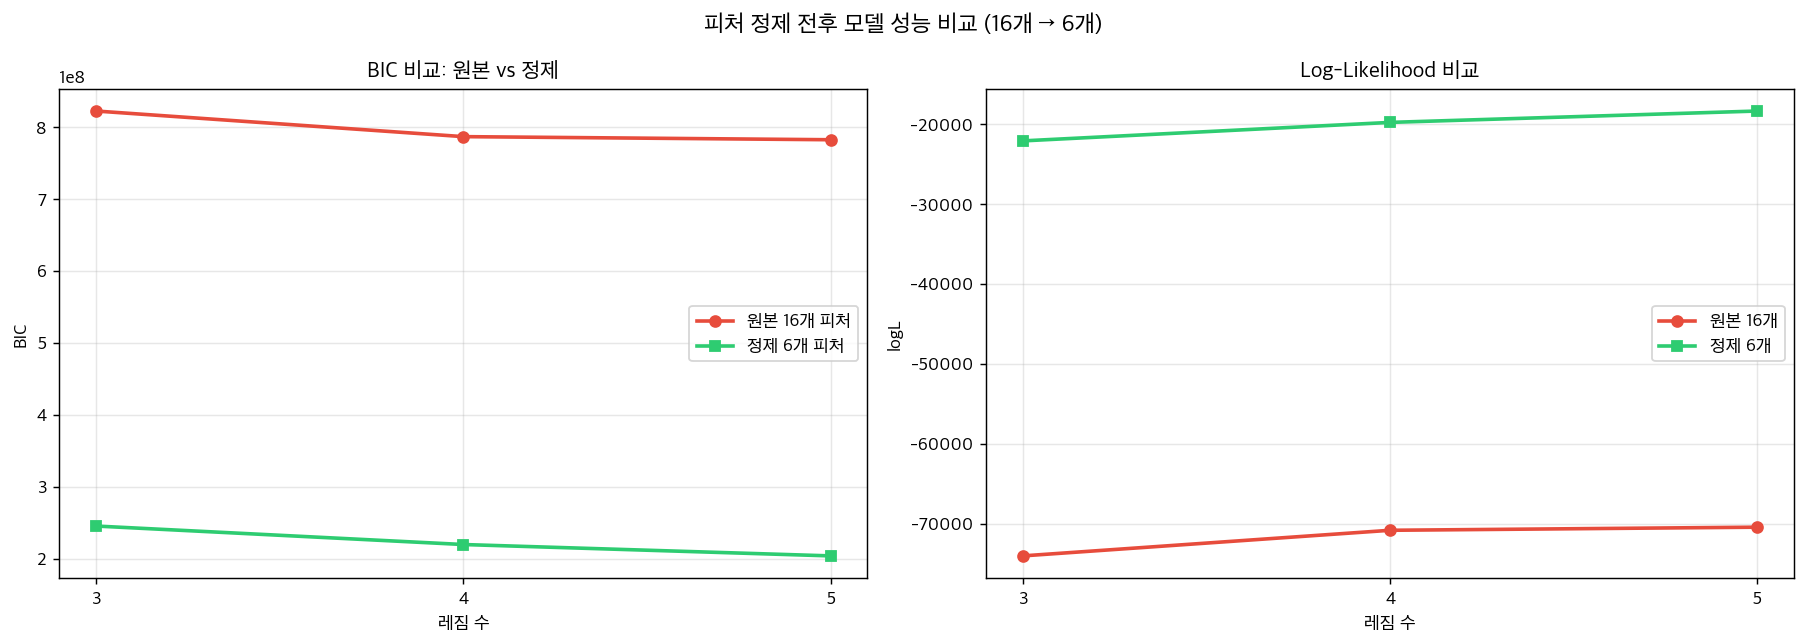


  n                  원본 BIC                  정제 BIC            ΔBIC  판정
------------------------------------------------------------------------------
  3             822447904.6             245343799.3    -577104105.2  ↓ 개선
  4             786832518.2             219632867.4    -567199650.8  ↓ 개선
  5             782517933.8             203819363.4    -578698570.4  ↓ 개선


In [76]:
# ── 피처 선택 & 스케일링 & n=3,4,5 학습 ─────────────────────────────────────
REFINED_FEATS = ["mkt_rf", "vol_21d", "vol_63d", "vix", "vix_chg", "t10y2y"]
feat_r   = feat_df[REFINED_FEATS]
scaler_r = StandardScaler()
X_r      = scaler_r.fit_transform(feat_r.values)

print(f"정제 피처 ({len(REFINED_FEATS)}개): {REFINED_FEATS}\n")
print(f"{'n':>3}  {'logL':>14}  {'BIC':>22}  수렴")
print("-" * 52)
results_r = {}
for n in [3, 4, 5]:
    r = fit_hmm(n, X_r, feat_r, seed=SEED)
    results_r[n] = r
    print(f"  {n}  {r['logL']:>14.2f}  {r['bic']:>22.1f}  {r['model'].monitor_.converged}")

best_n_r = min(results_r, key=lambda n: results_r[n]["bic"])
print(f"\n→ BIC 최적 n = {best_n_r}")

# ── 원본 vs 정제 BIC 비교 ─────────────────────────────────────────────────────
ns = [3, 4, 5]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ns, [results[n]["bic"]   for n in ns], marker="o", color="#e74c3c", lw=2, label="원본 16개 피처")
axes[0].plot(ns, [results_r[n]["bic"] for n in ns], marker="s", color="#2ecc71", lw=2, label="정제 6개 피처")
axes[0].set_title("BIC 비교: 원본 vs 정제", fontweight="bold", fontsize=12)
axes[0].set_xlabel("레짐 수"); axes[0].set_ylabel("BIC")
axes[0].set_xticks(ns); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ns, [results[n]["logL"]   for n in ns], marker="o", color="#e74c3c", lw=2, label="원본 16개")
axes[1].plot(ns, [results_r[n]["logL"] for n in ns], marker="s", color="#2ecc71", lw=2, label="정제 6개")
axes[1].set_title("Log-Likelihood 비교", fontweight="bold", fontsize=12)
axes[1].set_xlabel("레짐 수"); axes[1].set_ylabel("logL")
axes[1].set_xticks(ns); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("피처 정제 전후 모델 성능 비교 (16개 → 6개)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R1_bic_comparison_refined.png", bbox_inches="tight")
plt.show()

print(f"\n{'n':>3}  {'원본 BIC':>22}  {'정제 BIC':>22}  {'ΔBIC':>14}  판정")
print("-" * 78)
for n in ns:
    delta = results_r[n]["bic"] - results[n]["bic"]
    print(f"  {n}  {results[n]['bic']:>22.1f}  {results_r[n]['bic']:>22.1f}  "
          f"{delta:>+14.1f}  {'↓ 개선' if delta < 0 else '↑ 악화'}")

   정제 피처 기반 레짐 통계 (6개 피처)

── n=3  (BIC=245343799,  logL=-22087.12,  수렴=True)
  [Bull (강세)       ]   47.0%  (2610일)  수익=+0.082%  변동=0.640%  VIX=13.7
  [Neutral (중립)    ]   40.3%  (2236일)  수익=+0.016%  변동=1.044%  VIX=20.2
  [Bear (약세)       ]   12.7%  ( 708일)  수익=-0.031%  변동=2.224%  VIX=34.7

── n=4  (BIC=219632867,  logL=-19772.49,  수렴=True)
  [Bull (강세)       ]   31.5%  (1751일)  수익=+0.063%  변동=0.569%  VIX=13.0
  [Recovery (회복)   ]   30.3%  (1682일)  수익=+0.057%  변동=1.142%  VIX=21.3
  [Neutral (중립)    ]   27.0%  (1499일)  수익=+0.043%  변동=0.823%  VIX=16.2
  [Bear (약세)       ]   11.2%  ( 622일)  수익=-0.065%  변동=2.300%  VIX=36.0

── n=5  (BIC=203819363,  logL=-18348.88,  수렴=True) ◀ BIC 최적
  [Bull (강세)       ]   20.9%  (1162일)  수익=+0.099%  변동=0.758%  VIX=15.9
  [Mild Bull (완만)  ]   22.0%  (1222일)  수익=+0.070%  변동=0.553%  VIX=12.2
  [Neutral (중립)    ]   25.4%  (1412일)  수익=+0.036%  변동=0.803%  VIX=16.6
  [Volatile (고변동)  ]   23.0%  (1275일)  수익=+0.005%  변동=1.338%  VIX=23.8
  [Crisis (위기)     ]    8.7%

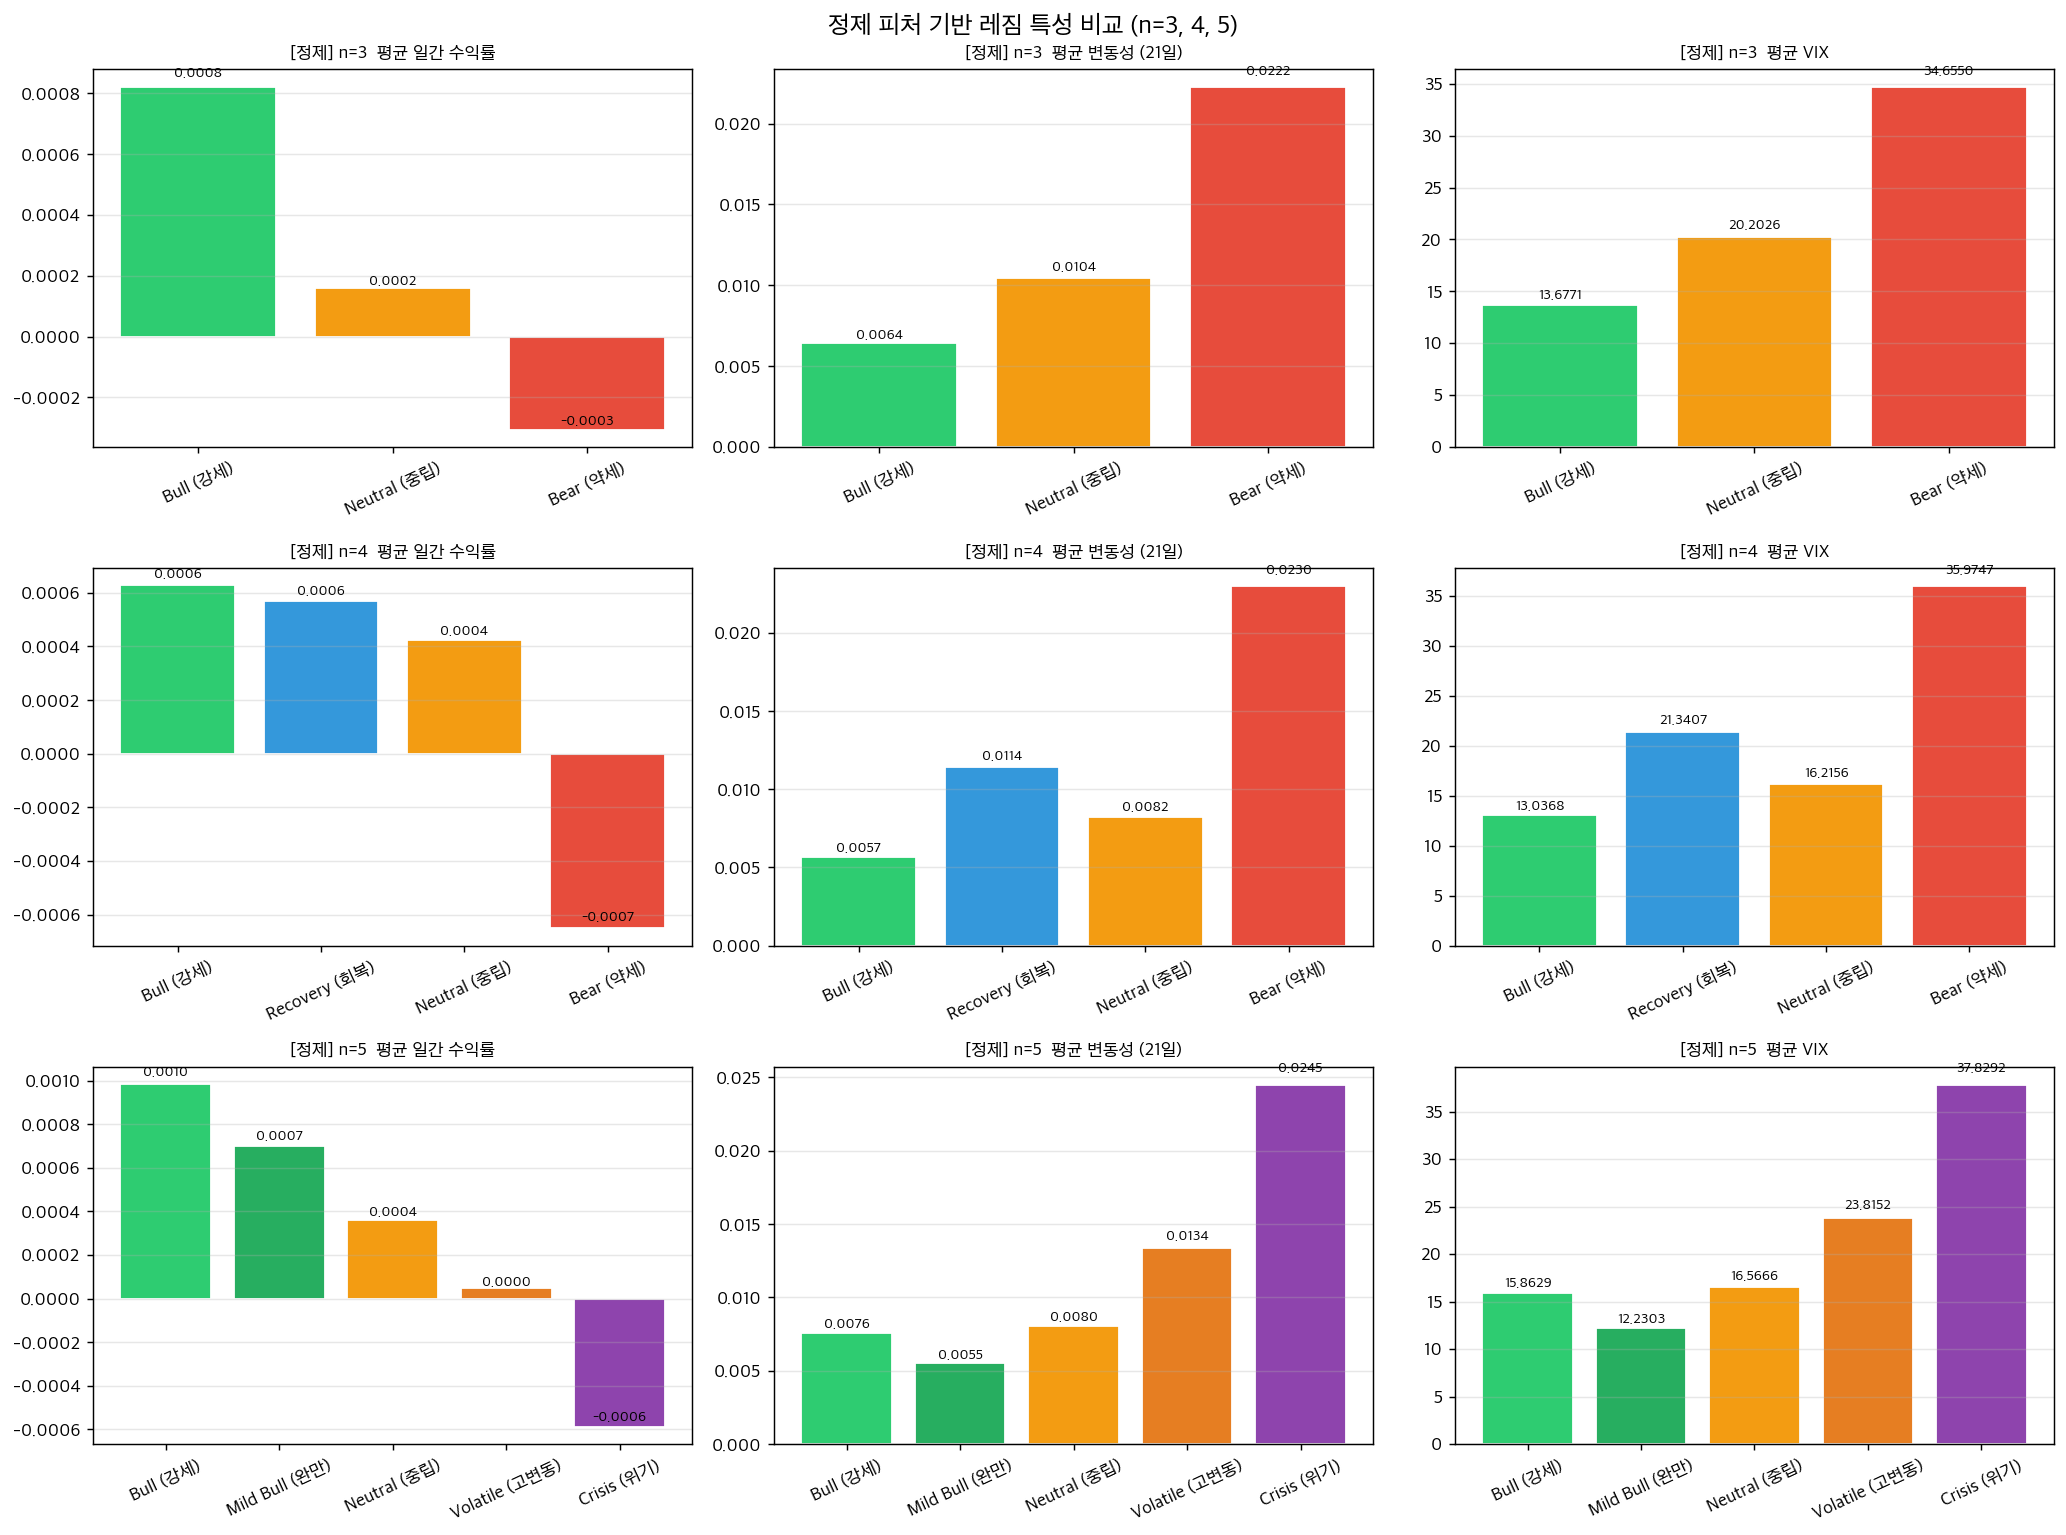

In [77]:
# ── 정제 피처 레짐 통계 ───────────────────────────────────────────────────────
print("=" * 72)
print("   정제 피처 기반 레짐 통계 (6개 피처)")
print("=" * 72)
for n in [3, 4, 5]:
    r    = results_r[n]
    mark = " ◀ BIC 최적" if n == best_n_r else ""
    print(f"\n── n={n}  (BIC={r['bic']:.0f},  logL={r['logL']:.2f},  수렴={r['model'].monitor_.converged}){mark}")
    for _, row in r["stats"].iterrows():
        print(f"  [{row['label']:<16}]  {row['pct']:5.1f}%  ({int(row['count']):4d}일)  "
              f"수익={row['mean_ret']*100:+.3f}%  "
              f"변동={row['mean_vol']*100:.3f}%  "
              f"VIX={row['mean_vix']:.1f}")

# ── 레짐 통계 바 차트 ─────────────────────────────────────────────────────────
metrics = [("mean_ret", "평균 일간 수익률"), ("mean_vol", "평균 변동성 (21일)"), ("mean_vix", "평균 VIX")]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for row_idx, n in enumerate([3, 4, 5]):
    r  = results_r[n]
    st = r["stats"]
    for col_idx, (col, title) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        colors = [get_color(row["label"], i) for i, row in st.iterrows()]
        bars   = ax.bar(st["label"], st[col], color=colors, edgecolor="white")
        ax.set_title(f"[정제] n={n}  {title}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, st[col]):
            if pd.notna(val):
                ypos = bar.get_height() + abs(bar.get_height()) * 0.03
                ax.text(bar.get_x() + bar.get_width()/2, ypos,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("정제 피처 기반 레짐 특성 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R2_regime_stats_refined.png", bbox_inches="tight")
plt.show()

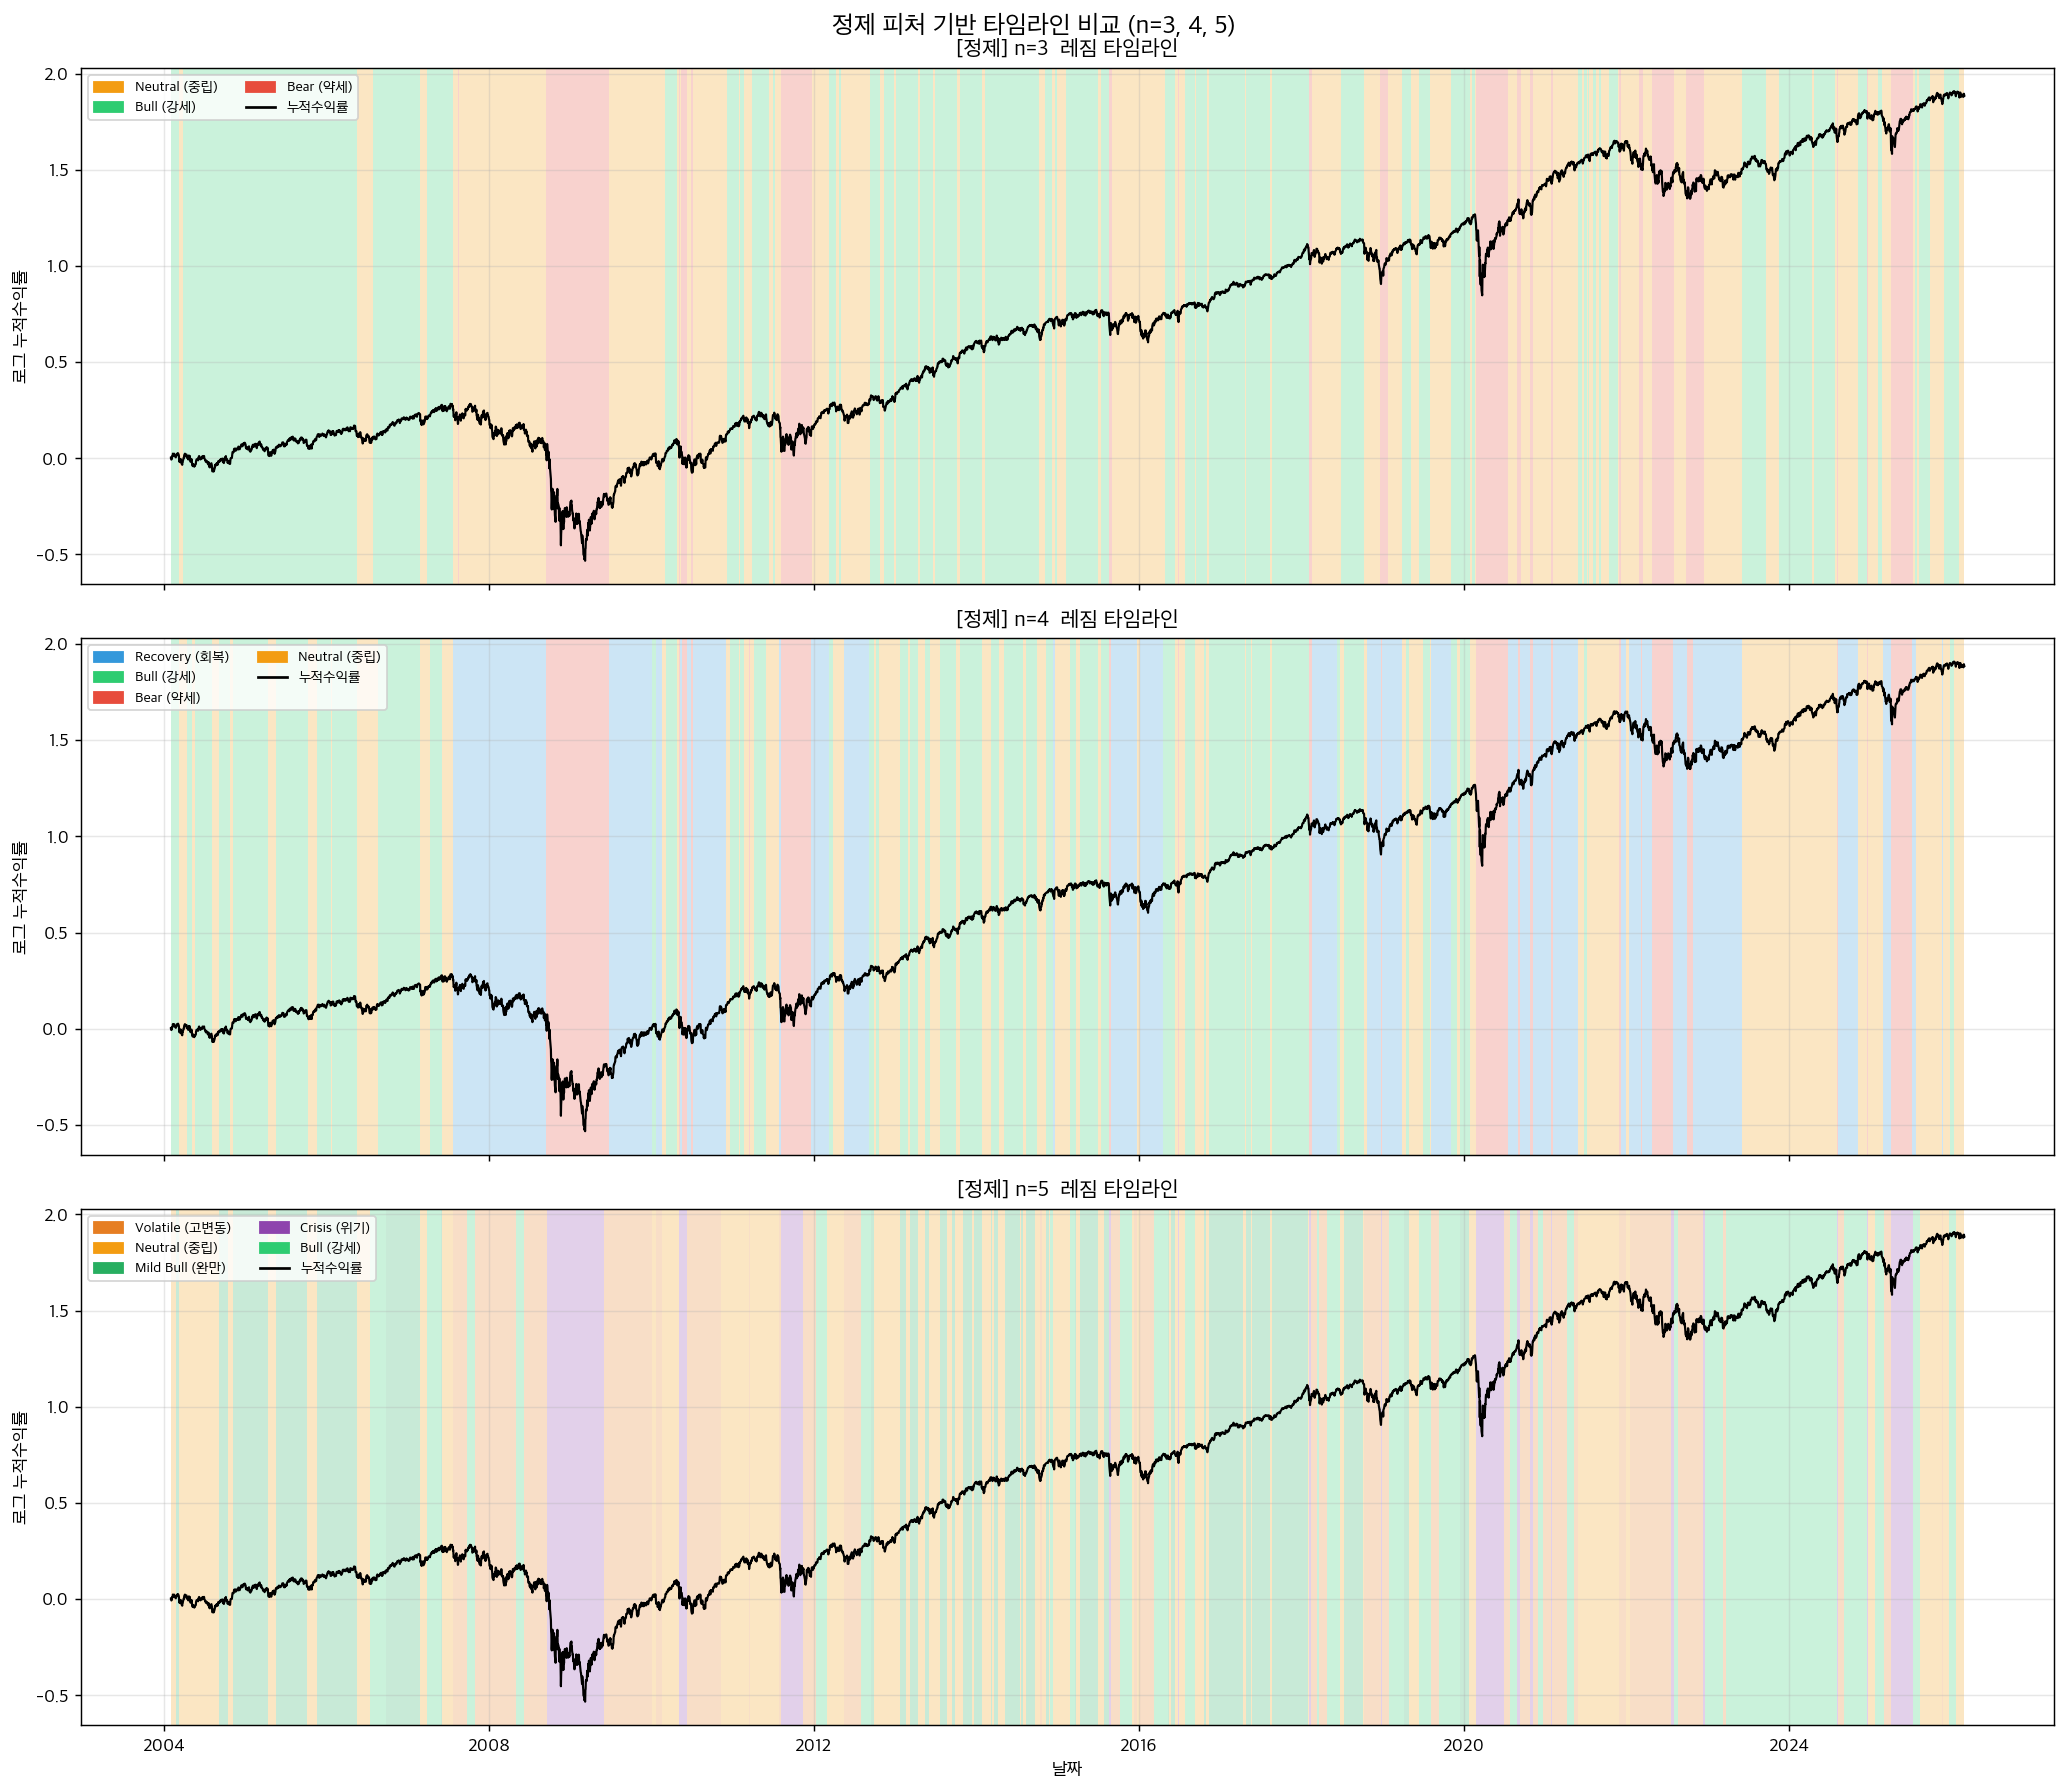

In [78]:
# ── 정제 피처 기반 타임라인 ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, n in zip(axes, [3, 4, 5]):
    r   = results_r[n]
    st  = r["states"]
    s2l = r["state_to_label"]
    uq  = sorted(s2l.keys())

    ax.plot(dates, mkt_cum.values, color="black", lw=1.2)

    prev_s = st[0]; t0 = dates[0]
    for i in range(1, len(st)):
        if st[i] != prev_s or i == len(st) - 1:
            lbl = s2l[prev_s]
            ax.axvspan(t0, dates[i], alpha=0.25, color=get_color(lbl, uq.index(prev_s)), lw=0)
            prev_s = st[i]; t0 = dates[i]

    patches = [mpatches.Patch(color=get_color(s2l[s], uq.index(s)), label=s2l[s]) for s in uq]
    ax.legend(handles=patches + [plt.Line2D([0],[0], color="black", lw=1.5, label="누적수익률")],
              loc="upper left", fontsize=8, ncol=2)
    ax.set_ylabel("로그 누적수익률")
    ax.set_title(f"[정제] n={n}  레짐 타임라인", fontweight="bold", fontsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("날짜")
plt.suptitle("정제 피처 기반 타임라인 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R3_timeline_refined.png", bbox_inches="tight")
plt.show()

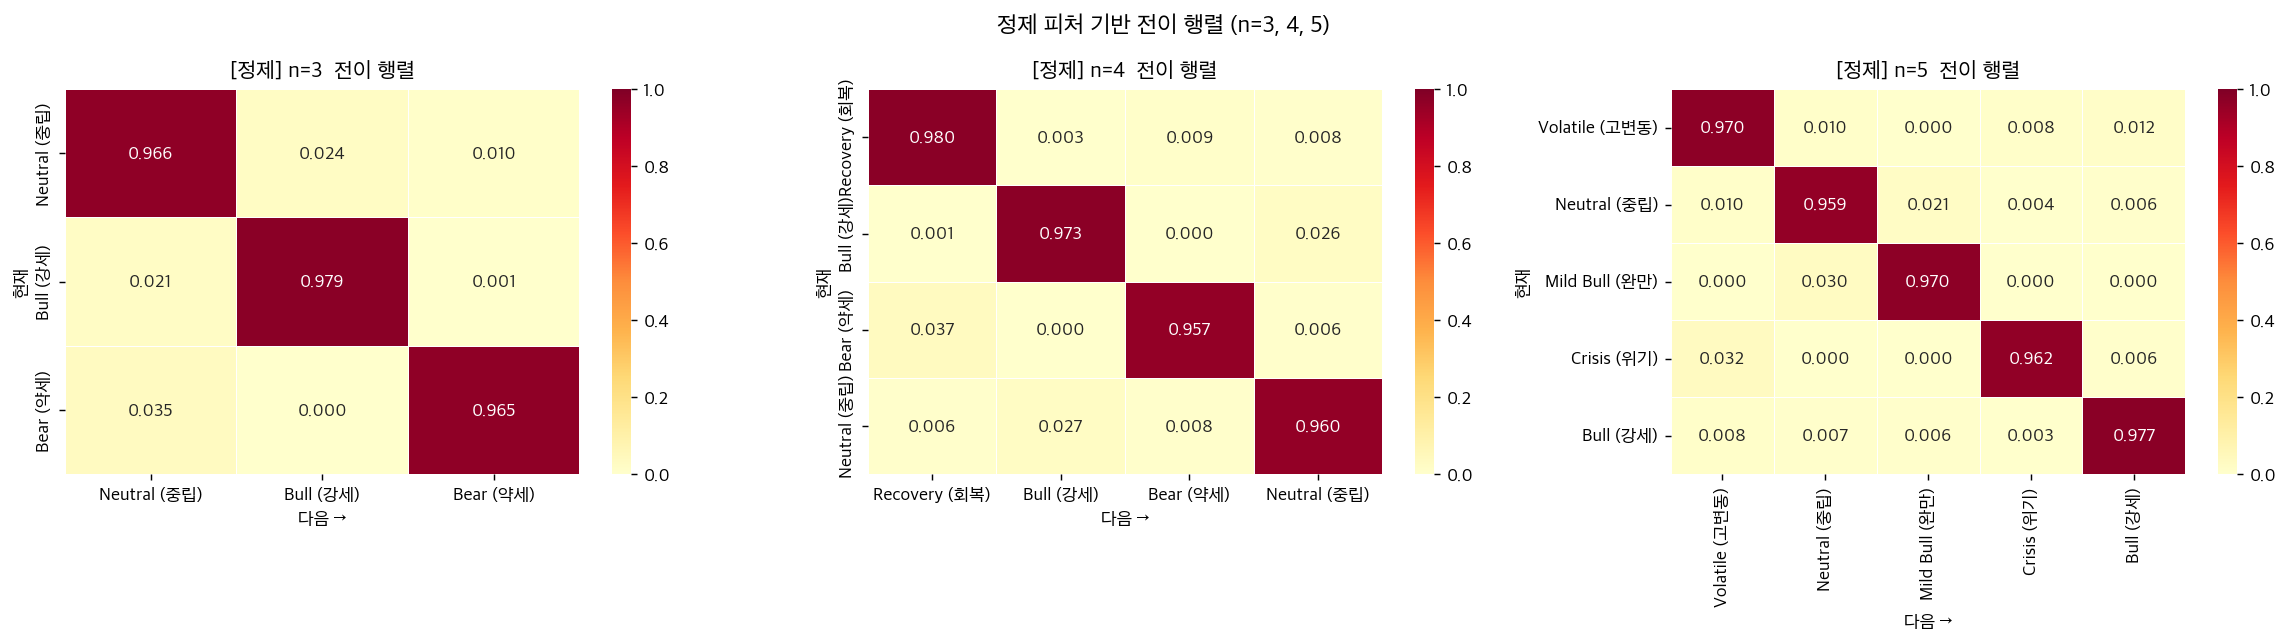

─── 최근 10일 레짐 (정제 모델, n=5) ─────────────────────────
  2026-02-13  →  Neutral (중립)
  2026-02-17  →  Neutral (중립)
  2026-02-18  →  Neutral (중립)
  2026-02-19  →  Neutral (중립)
  2026-02-20  →  Neutral (중립)
  2026-02-23  →  Neutral (중립)
  2026-02-24  →  Neutral (중립)
  2026-02-25  →  Neutral (중립)
  2026-02-26  →  Neutral (중립)
  2026-02-27  →  Neutral (중립)

✅ 정제 피처 결과 CSV 저장 완료
   - hmm_refined_n3_results.csv  /  hmm_refined_n3_summary.csv
   - hmm_refined_n4_results.csv  /  hmm_refined_n4_summary.csv
   - hmm_refined_n5_results.csv  /  hmm_refined_n5_summary.csv


In [79]:
# ── 정제 피처 기반 전이 행렬 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n in zip(axes, [3, 4, 5]):
    r        = results_r[n]
    labels   = [r["state_to_label"][i] for i in range(n)]
    trans_df = pd.DataFrame(r["model"].transmat_, index=labels, columns=labels)
    sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"[정제] n={n}  전이 행렬", fontweight="bold", fontsize=12)
    ax.set_xlabel("다음 →"); ax.set_ylabel("현재")

plt.suptitle("정제 피처 기반 전이 행렬 (n=3, 4, 5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R4_transition_refined.png", bbox_inches="tight")
plt.show()

# ── 최근 레짐 & CSV 저장 ─────────────────────────────────────────────────────
print(f"─── 최근 10일 레짐 (정제 모델, n={best_n_r}) ─────────────────────────")
for dt, s in zip(dates[-10:], results_r[best_n_r]["states"][-10:]):
    print(f"  {dt.date()}  →  {results_r[best_n_r]['state_to_label'][s]}")

for n in [3, 4, 5]:
    r   = results_r[n]
    out = feat_r[["mkt_rf", "vol_21d", "vix"]].copy()
    out["state"]  = r["states"]
    out["regime"] = [r["state_to_label"][s] for s in r["states"]]
    for i in range(n):
        out[f"prob_{r['state_to_label'][i]}"] = r["posterior"][:, i]
    out.to_csv(OUT_DIR / f"hmm_refined_n{n}_results.csv")
    r["stats"].to_csv(OUT_DIR / f"hmm_refined_n{n}_summary.csv", index=False)

print("\n✅ 정제 피처 결과 CSV 저장 완료")
for n in [3, 4, 5]:
    print(f"   - hmm_refined_n{n}_results.csv  /  hmm_refined_n{n}_summary.csv")